# Libraries

In [41]:
# !pip install tensorflow-addons
# !pip3 install kagglehub

# #Installing Qiskit Packages
# !pip install qiskit
# !pip install qiskit_machine_learning
# !pip install qiskit_algorithms
# !pip install qiskit_ibm_runtime

In [62]:
from pathlib import Path
# import tensorflow as tf
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import requests
import seaborn as sns

#Importing Libraries
from sklearn.svm import SVC

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#from qiskit.utils import algorithm_globals
from qiskit.circuit.library import PauliFeatureMap, ZZFeatureMap
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit.circuit import QuantumCircuit
from qiskit import transpile
from qiskit.circuit.library import RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import BaseSampler
#from qiskit.primitives import Sampler
#from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from sklearn.pipeline import make_pipeline
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit import transpile
from sklearn.svm import SVC
import pandas as pd
import time

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import adjusted_rand_score
from qiskit import transpile, QuantumCircuit

np.random.seed(42)
#algorithm_globals.random_seed = 123

# Dataset

[ClaMp](https://www.kaggle.com/code/ssmohanty/dimensionality-reduction-techniques)

In [63]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("saurabhshahane/classification-of-malwares")

# print("Path to dataset files:", path)

In [64]:
import pandas as pd
import os

# Define the dataset path
dataset_path = "/Users/sthefaniepasso/.cache/kagglehub/datasets/saurabhshahane/classification-of-malwares/versions/1"

# List files in the directory to find the CSV file
files = os.listdir(dataset_path)
csv_files = [f for f in files if f.endswith('.csv')]

# Load the first CSV file (assuming there's only one)
if csv_files:
    df = pd.read_csv(os.path.join(dataset_path, csv_files[0]))
    print("CSV found and send to df")  # Display first few rows
else:
    print("No CSV file found in the dataset directory.")

#/home/ats852/.cache/kagglehub/datasets/saurabhshahane/classification-of-malwares/versions/1

CSV found and send to df


In [65]:
df.head()

,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
0,23117,144,3,0,4,0,65535,0,184,0,...,1194954,3,64,1048576,4096,1048576,4096,0,16,0
1,23117,144,3,0,4,0,65535,0,184,0,...,0,2,0,1048576,4096,1048576,4096,0,16,0
2,23117,144,3,0,4,0,65535,0,184,0,...,67688,2,320,1048576,4096,1048576,4096,0,16,0
3,23117,144,3,0,4,0,65535,0,184,0,...,113668,2,1344,1048576,4096,1048576,4096,0,16,0
4,23117,144,3,0,4,0,65535,0,184,0,...,69089,2,33088,262144,8192,1048576,4096,0,16,0


In [66]:
target = 'class'

In [67]:
import pandas as pd

def create_balanced_sample(df, target_column='class', num_samples=1000):
    # Ensure that num_samples is even to allow 50/50 split
    if num_samples % 2 != 0:
        raise ValueError("Number of samples must be even to ensure 50% distribution of labels.")

    # Split the data into two groups: one for each class
    class_0 = df[df[target_column] == 0]
    class_1 = df[df[target_column] == 1]
    
    # Find the minimum number of samples between the two classes to avoid imbalance issues
    min_class_size = min(len(class_0), len(class_1))
    
    if min_class_size * 2 < num_samples:
        raise ValueError(f"Not enough data to create a balanced dataset of {num_samples} samples.")

    # Sample from each class to ensure 50/50 split
    half_samples = num_samples // 2
    class_0_sample = class_0.sample(n=half_samples)
    class_1_sample = class_1.sample(n=half_samples)
    
    # Concatenate the two samples to form the balanced dataset
    df_n = pd.concat([class_0_sample, class_1_sample]).sample(frac=1).reset_index(drop=True)  # Shuffle and reset index
    
    return df_n

# Usage
df = df.drop(columns=["e_magic", "e_crlc"])
y = df[target]
X = df.drop(columns=[target])

# Create balanced sample
# df_n = create_balanced_sample(df)
df_n = df
print(df_n.shape)

(5184, 54)


In [68]:
print(df.isna().sum())

e_cblp                            0
e_cp                              0
e_cparhdr                         0
e_minalloc                        0
e_maxalloc                        0
e_ss                              0
e_sp                              0
e_csum                            0
e_ip                              0
e_cs                              0
e_lfarlc                          0
e_ovno                            0
e_res                          5184
e_oemid                           0
e_oeminfo                         0
e_res2                         5184
e_lfanew                          0
Machine                           0
NumberOfSections                  0
CreationYear                      0
PointerToSymbolTable              0
NumberOfSymbols                   0
SizeOfOptionalHeader              0
Characteristics                   0
Magic                             0
MajorLinkerVersion                0
MinorLinkerVersion                0
SizeOfCode                  

In [69]:
#df.dropna(axis=1, inplace=True)
df_cleaned = df.dropna(axis=1)
print(df.isna().sum())

e_cblp                            0
e_cp                              0
e_cparhdr                         0
e_minalloc                        0
e_maxalloc                        0
e_ss                              0
e_sp                              0
e_csum                            0
e_ip                              0
e_cs                              0
e_lfarlc                          0
e_ovno                            0
e_res                          5184
e_oemid                           0
e_oeminfo                         0
e_res2                         5184
e_lfanew                          0
Machine                           0
NumberOfSections                  0
CreationYear                      0
PointerToSymbolTable              0
NumberOfSymbols                   0
SizeOfOptionalHeader              0
Characteristics                   0
Magic                             0
MajorLinkerVersion                0
MinorLinkerVersion                0
SizeOfCode                  

# Correlation Heatmaps with Hierarchical Clustering

[Examples](https://www.kaggle.com/code/sgalella/correlation-heatmaps-with-hierarchical-clustering)

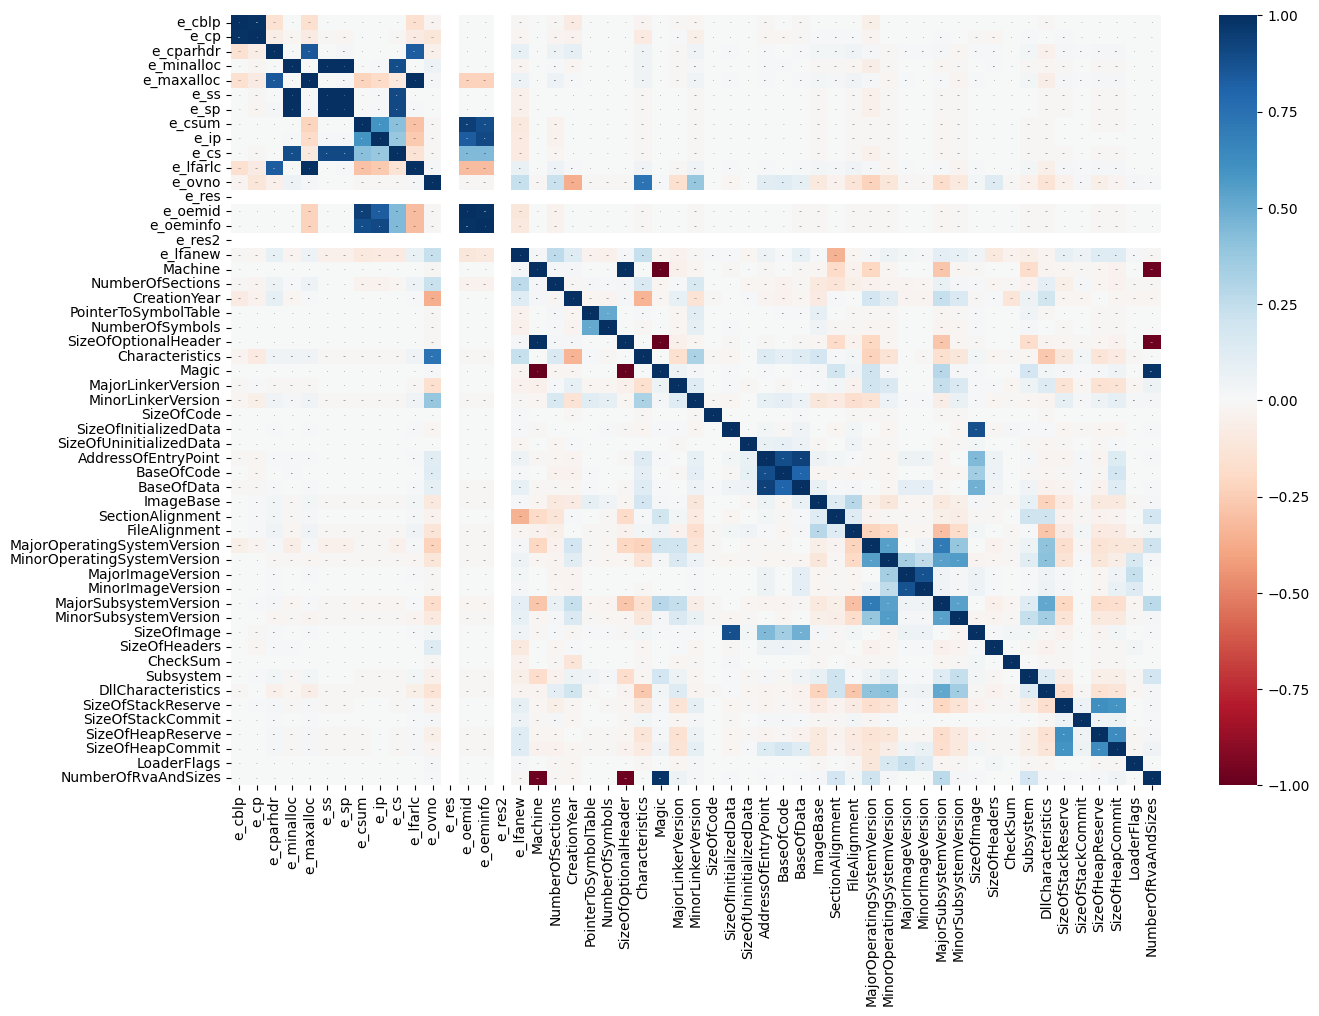

In [70]:
data = df.drop(columns=[target])#'Class',
plt.figure(figsize=(15,10))
correlations = data.corr()
sns.heatmap(round(correlations,2), cmap='RdBu', annot=True, 
            annot_kws={"size": 0.2}, vmin=-1, vmax=1);

In [71]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

class MinimalDataProcessor:
    def __init__(self, dataset_path, target_col='class', exclude_cols=None, num_samples=1000):
        self.dataset_path = dataset_path
        self.target_col = target_col
        self.exclude_cols = exclude_cols or ["e_magic", "e_crlc"]
        self.num_samples = num_samples
        self.df = None
        self.feature_2to10 = []
        self.all_features = []  # Store all features for "all" option
    
    def load_and_balance_data(self):
        # Load CSV
        csv_files = [f for f in os.listdir(self.dataset_path) if f.endswith('.csv')]
        self.df = pd.read_csv(os.path.join(self.dataset_path, csv_files[0]))
        
        # Drop excluded columns and balance dataset
        self.df = self.df.drop(columns=self.exclude_cols, errors='ignore')
        class_0 = self.df[self.df[self.target_col] == 0].sample(n=self.num_samples//2)
        class_1 = self.df[self.df[self.target_col] == 1].sample(n=self.num_samples//2)
        self.df = pd.concat([class_0, class_1]).sample(frac=1).reset_index(drop=True)
        
        # Store all features (excluding target)
        self.all_features = [col for col in self.df.columns if col != self.target_col]
        
        return self.df
    
    def _get_representative_feature(self, cluster_features, corr_matrix):
        if len(cluster_features) == 1:
            return cluster_features[0]
        scores = {f: np.mean([abs(corr_matrix.loc[f, other]) 
                            for other in cluster_features if other != f]) 
                 for f in cluster_features}
        return max(scores, key=scores.get)
    
    def generate_feature_clusters(self, min_clusters=2, max_clusters=10):
        data = self.df.drop(columns=[self.target_col])
        
        # Remove constant features that cause correlation issues
        data = data.loc[:, data.std() > 1e-6]
        
        correlations = data.corr().abs().fillna(0)
        
        # Clip correlations to valid range [0, 1]
        correlations = correlations.clip(0, 1)
        
        # Create dissimilarity matrix
        dissimilarity = 1 - correlations
        
        # Ensure perfect symmetry and valid distance properties
        dissimilarity = (dissimilarity + dissimilarity.T) / 2
        np.fill_diagonal(dissimilarity.values, 0)  # Distance to self = 0
        
        # Ensure all values are non-negative
        dissimilarity = dissimilarity.clip(0, None)
        
        try:
            Z = linkage(squareform(dissimilarity), 'ward')
        except ValueError:
            # Fallback: use average linkage if ward fails
            Z = linkage(squareform(dissimilarity), 'average')
        
        for n_clusters in range(min_clusters, max_clusters + 1):
            labels = fcluster(Z, n_clusters, criterion='maxclust')
            
            # Group features by cluster
            clusters = {}
            for idx, feature in enumerate(data.columns):
                cluster_id = labels[idx]
                clusters.setdefault(cluster_id, []).append(feature)
            
            # Get representative features
            representatives = [self._get_representative_feature(features, correlations) 
                             for features in clusters.values()]
            self.feature_2to10.append(representatives)
        
        return self.feature_2to10
    
    def _cluster_and_reorder_features(self, features, n_clusters=None):
        """Cluster features and return them ordered by cluster groups"""
        if len(features) <= 1:
            return features
        
        data = self.df[features]
        correlations = data.corr().abs().fillna(0).clip(0, 1)
        dissimilarity = 1 - correlations
        dissimilarity = (dissimilarity + dissimilarity.T) / 2
        np.fill_diagonal(dissimilarity.values, 0)
        dissimilarity = dissimilarity.clip(0, None)
        
        try:
            Z = linkage(squareform(dissimilarity), 'ward')
        except ValueError:
            Z = linkage(squareform(dissimilarity), 'average')
        
        # Determine number of clusters
        if n_clusters is None:
            n_clusters = min(10, max(2, len(features) // 5))
        
        cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
        
        # Group features by cluster and order them
        cluster_groups = {}
        for feature, cluster_id in zip(features, cluster_labels):
            cluster_groups.setdefault(cluster_id, []).append(feature)
        
        # Create ordered feature list (all cluster 1, then all cluster 2, etc.)
        ordered_features = []
        for cluster_id in sorted(cluster_groups.keys()):
            ordered_features.extend(sorted(cluster_groups[cluster_id]))
        
        return ordered_features
    
    def plot_10d_correlation_heatmap(self, figsize=(12, 10)):
        """Plot correlation heatmap with FORCED cluster grouping for 10D features"""
        if not self.feature_2to10:
            print("Run generate_feature_clusters() first")
            return
        
        # Get 10D features (index 8 = 10 clusters)
        features_10d = self.feature_2to10[8]  # 10D is at index 8 (10-2)
        
        # Force cluster grouping
        ordered_features, cluster_assignments = self._force_cluster_grouping(features_10d, n_clusters=5)
        data_10d = self.df[ordered_features]
        correlations = data_10d.corr()
        
        # Plot heatmap with forced cluster boundaries
        plt.figure(figsize=figsize)
        ax = sns.heatmap(correlations, annot=True, cmap='RdBu', 
                        vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
        
        # Add cluster boundaries based on forced grouping
        cluster_boundaries = self._get_cluster_boundaries(cluster_assignments)
        
        for boundary in cluster_boundaries:
            ax.axhline(y=boundary, color='white', linewidth=3)
            ax.axvline(x=boundary, color='white', linewidth=3)
        
        # Add cluster labels based on forced grouping
        cluster_starts = [0] + cluster_boundaries + [len(cluster_assignments)]
        for i in range(len(cluster_starts) - 1):
            start = cluster_starts[i]
            end = cluster_starts[i + 1]
            mid_point = (start + end) / 2
            cluster_id = cluster_assignments[start]
            
            ax.text(mid_point, -0.5, f'C{cluster_id}', 
                   fontweight='bold', fontsize=12, ha='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))
            ax.text(len(correlations) + 0.2, mid_point, f'C{cluster_id}', 
                   fontweight='bold', fontsize=12, ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))
        
        plt.title('10D Features Heatmap with FORCED Cluster Grouping', 
                 fontsize=14, pad=20)
        plt.tight_layout()
        plt.show()
        
        # Print cluster summary
        print(f"\n10D Features FORCED Clustering Summary:")
        print(f"Ordered features (grouped by cluster): {ordered_features}")
        self._print_forced_cluster_summary(ordered_features, cluster_assignments, "10D")
    
    def plot_10d_clustermap(self, figsize=(12, 12)):
        """Plot clustermap for 10D features with FORCED cluster grouping"""
        if not self.feature_2to10:
            print("Run generate_feature_clusters() first")
            return
        
        features_10d = self.feature_2to10[8]
        
        # Force cluster grouping
        ordered_features, cluster_assignments = self._force_cluster_grouping(features_10d, n_clusters=5)
        data_10d = self.df[ordered_features]
        correlations = data_10d.corr()
        
        # Create clustermap with clustering DISABLED to preserve our ordering
        g = sns.clustermap(correlations, method="complete", cmap='RdBu', 
                          annot=True, vmin=-1, vmax=1, figsize=figsize,
                          row_cluster=False, col_cluster=False, square=True)  # Disable clustering
        
        ax_heatmap = g.ax_heatmap
        
        # Add cluster boundaries based on forced grouping
        cluster_boundaries = self._get_cluster_boundaries(cluster_assignments)
        
        for boundary in cluster_boundaries:
            ax_heatmap.axhline(y=boundary, color='white', linewidth=3, alpha=0.9)
            ax_heatmap.axvline(x=boundary, color='white', linewidth=3, alpha=0.9)
        
        # Add forced cluster labels
        self._add_forced_cluster_labels(ax_heatmap, cluster_assignments, cluster_boundaries)
        
        g.fig.suptitle('10D Features with FORCED Cluster Grouping', fontsize=16, y=1.02)
        plt.show()
        
        # Print summary
        self._print_forced_cluster_summary(ordered_features, cluster_assignments, "10D")
    
    def get_features(self, n_clusters):
        """Get representative features for n clusters (2-10) or all features"""
        if n_clusters == "all":
            return self.all_features
        return self.feature_2to10[n_clusters - 2] if 2 <= n_clusters <= 10 else None
    
    def get_subset(self, n_clusters, include_target=True):
        """Get DataFrame with representative features"""
        features = self.get_features(n_clusters)
        if include_target and features:
            return self.df[features + [self.target_col]]
        return self.df[features] if features else None
    
    def _select_features_for_dimensions(self, n_dimensions):
        """Select features based on dimension count with intelligent selection"""
        if n_dimensions == "all":
            return self.all_features
            
        if n_dimensions <= 10:
            # Use feature_2to10 for dimensions 2-10
            return self.feature_2to10[n_dimensions - 2]
        else:
            # For >10 dimensions: use 10D features + add least correlated from each cluster
            base_features = self.feature_2to10[8]  # 10D features (index 8)
            selected_features = base_features.copy()
            
            if n_dimensions <= len(base_features):
                return selected_features[:n_dimensions]
            
            # Need more features - get original clustering data
            data = self.df.drop(columns=[self.target_col])
            data = data.loc[:, data.std() > 1e-6]
            correlations = data.corr().abs().fillna(0).clip(0, 1)
            dissimilarity = 1 - correlations
            dissimilarity = (dissimilarity + dissimilarity.T) / 2
            np.fill_diagonal(dissimilarity.values, 0)
            dissimilarity = dissimilarity.clip(0, None)
            
            try:
                Z = linkage(squareform(dissimilarity), 'ward')
            except ValueError:
                Z = linkage(squareform(dissimilarity), 'average')
            
            # Get 10 clusters to match our base features
            cluster_labels = fcluster(Z, 10, criterion='maxclust')
            
            # Group all features by their 10 clusters
            clusters = {}
            for idx, feature in enumerate(data.columns):
                cluster_id = cluster_labels[idx]
                clusters.setdefault(cluster_id, []).append(feature)
            
            # Map each base feature to its cluster
            feature_to_cluster = {}
            for cluster_id, cluster_features in clusters.items():
                for base_feature in base_features:
                    if base_feature in cluster_features:
                        feature_to_cluster[base_feature] = cluster_id
                        break
            
            # Add additional features from each cluster (least correlated to existing)
            additional_needed = n_dimensions - len(selected_features)
            added_count = 0
            
            # Cycle through clusters to add features evenly
            for cycle in range((additional_needed // len(feature_to_cluster)) + 1):
                if added_count >= additional_needed:
                    break
                    
                for base_feature in base_features:
                    if added_count >= additional_needed:
                        break
                        
                    cluster_id = feature_to_cluster.get(base_feature)
                    if cluster_id is None:
                        continue
                        
                    cluster_features = clusters[cluster_id]
                    available_features = [f for f in cluster_features if f not in selected_features]
                    
                    if not available_features:
                        continue
                    
                    # Find feature least correlated with the base feature from this cluster
                    correlations_with_base = {}
                    for candidate in available_features:
                        corr_val = abs(correlations.loc[base_feature, candidate])
                        correlations_with_base[candidate] = corr_val
                    
                    # Select feature with lowest correlation to base feature
                    least_correlated = min(correlations_with_base.keys(), 
                                         key=correlations_with_base.get)
                    selected_features.append(least_correlated)
                    added_count += 1
            
            return selected_features[:n_dimensions]  # Ensure exact count
    
    def plot_features_clustermap(self, n_dimensions, figsize=(16, 16)):
        """Plot hierarchical clustermap for selected features with cluster boundary lines and FORCED grouped features"""
        if self.df is None:
            print("Load data first")
            return
        
        # Select features based on dimensions
        if n_dimensions != "all" and n_dimensions <= 10 and not self.feature_2to10:
            print("Run generate_feature_clusters() first for dimensions <= 10")
            return
        
        selected_features = self._select_features_for_dimensions(n_dimensions)
        
        if not selected_features:
            print(f"Could not select features for {n_dimensions} dimensions")
            return
        
        print(f"Selected {len(selected_features)} features for {n_dimensions}D visualization:")
        if n_dimensions == "all":
            print(f"Using ALL features: {len(selected_features)} total")
        elif n_dimensions <= 10:
            print(f"Using feature_2to10[{n_dimensions-2}]: {selected_features}")
        else:
            base_features = self.feature_2to10[8]
            additional_features = [f for f in selected_features if f not in base_features]
            print(f"Base 10D features: {base_features}")
            print(f"Additional features (least correlated within clusters): {additional_features}")
        
        # FORCE CLUSTER GROUPING - this is the key fix
        if n_dimensions == "all":
            n_clusters = min(15, max(5, len(selected_features) // 10))  # Adaptive for large datasets
        else:
            n_clusters = min(10, len(selected_features))
        
        ordered_features, cluster_assignments = self._force_cluster_grouping(selected_features, n_clusters=n_clusters)
        
        data_selected = self.df[ordered_features]
        correlations = data_selected.corr().fillna(0).clip(-1, 1)
        correlations = correlations.replace([np.inf, -np.inf], 0)
        correlations = (correlations + correlations.T) / 2
        
        try:
            # Determine annotation and font size based on number of features
            show_annotations = len(ordered_features) <= 20
            annot_fontsize = max(8, 16 - len(ordered_features) // 3)  # Bigger font, adaptive
            
            # Create clustermap but DISABLE clustering to preserve our ordering
            g = sns.clustermap(correlations, method="complete", cmap='RdBu', 
                              annot=show_annotations, 
                              annot_kws={"size": annot_fontsize},  # Bigger correlation numbers
                              fmt='.2f',  # 2 decimal places
                              vmin=-1, vmax=1, figsize=figsize,
                              row_cluster=False, col_cluster=False, square=True)  # DISABLE clustering
            
            ax_heatmap = g.ax_heatmap
            
            # Add cluster boundaries based on our forced grouping
            cluster_boundaries = self._get_cluster_boundaries(cluster_assignments)
            
            for boundary in cluster_boundaries:
                ax_heatmap.axhline(y=boundary, color='white', linewidth=4, alpha=0.9)
                ax_heatmap.axvline(x=boundary, color='white', linewidth=4, alpha=0.9)
            
            # Add cluster labels based on our forced grouping
            self._add_forced_cluster_labels(ax_heatmap, cluster_assignments, cluster_boundaries)
            
            title_suffix = f"ALL ({len(selected_features)})" if n_dimensions == "all" else f"{n_dimensions}D"
            title = f'{title_suffix} Features with FORCED Cluster Grouping ({n_clusters} clusters)'
            g.fig.suptitle(title, fontsize=14, y=1.02)
            plt.show()
            
            # Print cluster summary
            self._print_forced_cluster_summary(ordered_features, cluster_assignments, n_dimensions)
            
        except Exception as e:
            print(f"Error creating clustermap: {e}")
    
    def _force_cluster_grouping(self, features, n_clusters=None):
        """Force features to be grouped by clusters and return ordered features with cluster assignments"""
        if len(features) <= 1:
            return features, [1] * len(features)
        
        data = self.df[features]
        correlations = data.corr().abs().fillna(0).clip(0, 1)
        dissimilarity = 1 - correlations
        dissimilarity = (dissimilarity + dissimilarity.T) / 2
        np.fill_diagonal(dissimilarity.values, 0)
        dissimilarity = dissimilarity.clip(0, None)
        
        try:
            Z = linkage(squareform(dissimilarity), 'ward')
        except ValueError:
            Z = linkage(squareform(dissimilarity), 'average')
        
        # Determine number of clusters
        if n_clusters is None:
            n_clusters = min(10, max(2, len(features) // 5))
        
        cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
        
        # Group features by cluster and force them to be together
        cluster_groups = {}
        for feature, cluster_id in zip(features, cluster_labels):
            cluster_groups.setdefault(cluster_id, []).append(feature)
        
        # Create ordered feature list (all cluster 1, then all cluster 2, etc.)
        ordered_features = []
        ordered_cluster_assignments = []
        
        for cluster_id in sorted(cluster_groups.keys()):
            cluster_features = sorted(cluster_groups[cluster_id])  # Sort within cluster
            ordered_features.extend(cluster_features)
            ordered_cluster_assignments.extend([cluster_id] * len(cluster_features))
        
        print(f"FORCED grouping: Features ordered by clusters")
        for cluster_id in sorted(cluster_groups.keys()):
            print(f"  Cluster {cluster_id}: {cluster_groups[cluster_id]}")
        
        return ordered_features, ordered_cluster_assignments
    
    def _get_cluster_boundaries(self, cluster_assignments):
        """Get cluster boundary positions from cluster assignments"""
        boundaries = []
        current_cluster = cluster_assignments[0]
        for i, cluster_id in enumerate(cluster_assignments):
            if cluster_id != current_cluster:
                boundaries.append(i)
                current_cluster = cluster_id
        return boundaries
    
    def _add_forced_cluster_labels(self, ax, cluster_assignments, cluster_boundaries):
        """Add cluster labels based on forced cluster grouping"""
        cluster_starts = [0] + cluster_boundaries + [len(cluster_assignments)]
        
        for i in range(len(cluster_starts) - 1):
            start = cluster_starts[i]
            end = cluster_starts[i + 1]
            mid_point = (start + end) / 2
            cluster_id = cluster_assignments[start]
            
            # Row labels (LEFT)
            ax.text(-1.5, mid_point, f'C{cluster_id}', 
                   fontweight='bold', fontsize=12, ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))
            
            # Column labels (TOP)
            ax.text(mid_point, -1.5, f'C{cluster_id}', 
                   fontweight='bold', fontsize=12, ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))
    
    def _print_forced_cluster_summary(self, ordered_features, cluster_assignments, n_dimensions):
        """Print summary of forced cluster grouping"""
        print(f"\nFORCED Cluster Summary for {n_dimensions}:")
        print(f"Features are GUARANTEED to be grouped by cluster (no dendrogram reordering)")
        print(f"Ordered features: {ordered_features}")
        
        # Group features by cluster for summary
        cluster_groups = {}
        for feature, cluster_id in zip(ordered_features, cluster_assignments):
            cluster_groups.setdefault(cluster_id, []).append(feature)
        
        print(f"\nCluster groups (in matrix order):")
        for cluster_id in sorted(cluster_groups.keys()):
            features = cluster_groups[cluster_id]
            print(f"Cluster {cluster_id} ({len(features)} features): {features}")
    
    
    def _find_boundaries(self, cluster_labels):
        """Find cluster boundary positions"""
        boundaries = []
        current_cluster = cluster_labels[0]
        for i, cluster_id in enumerate(cluster_labels):
            if cluster_id != current_cluster:
                boundaries.append(i)
                current_cluster = cluster_id
        return boundaries
    
    def _add_external_cluster_labels(self, ax, row_boundaries, col_boundaries, row_labels, col_labels):
        """Add cluster labels OUTSIDE the correlation matrix (to the left and top)"""
        # Row cluster labels on the LEFT (outside the matrix)
        row_starts = [0] + row_boundaries + [len(row_labels)]
        for i in range(len(row_starts) - 1):
            start = row_starts[i]
            end = row_starts[i + 1]
            mid_point = (start + end) / 2
            cluster_id = row_labels[start] if start < len(row_labels) else row_labels[-1]
            
            ax.text(-1.5, mid_point, f'C{cluster_id}', 
                   fontweight='bold', fontsize=12, ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))
        
        # Column cluster labels at the TOP (outside the matrix)
        col_starts = [0] + col_boundaries + [len(col_labels)]
        for i in range(len(col_starts) - 1):
            start = col_starts[i]
            end = col_starts[i + 1]
            mid_point = (start + end) / 2
            cluster_id = col_labels[start] if start < len(col_labels) else col_labels[-1]
            
            ax.text(mid_point, -1.5, f'C{cluster_id}', 
                   fontweight='bold', fontsize=12, ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))
    
    def run_all(self, plotd=10):
        """Complete pipeline with customizable dimension plotting"""
        self.load_and_balance_data()
        
        if plotd != "all":
            self.generate_feature_clusters()
            print(f"Generated feature_2to10 with {len(self.feature_2to10)} entries")
            for i, features in enumerate(self.feature_2to10):
                print(f"  {i+2}D: {len(features)} features - {features}")
        else:
            print(f"Processing ALL features: {len(self.all_features)} total")
            # Still generate clustering for consistency but won't use feature_2to10
            self.generate_feature_clusters()
        
        if plotd:
            if plotd == "all":
                print(f"\nGenerating correlation plot for ALL {len(self.all_features)} features...")
            else:
                print(f"\nGenerating {plotd}D correlation plots...")
            
            if plotd == 10:
                # Special case: show both 10D specific plots and clustermap
                self.plot_10d_correlation_heatmap()
                self.plot_10d_clustermap()
            
            # Always show the customizable clustermap
            self.plot_features_clustermap(plotd)
        
        return self.feature_2to10 if plotd != "all" else self.all_features

# Usage:
"""
processor = MinimalDataProcessor(
    dataset_path="/path/to/dataset"
)

# Plot all features with grouped clusters
all_features = processor.run_all(plotd="all")

# Plot 52D with grouped clusters
feature_52d = processor.run_all(plotd=52)

# Plot 10D with special plots
feature_10d = processor.run_all(plotd=10)
"""

'\nprocessor = MinimalDataProcessor(\n    dataset_path="/path/to/dataset"\n)\n\n# Plot all features with grouped clusters\nall_features = processor.run_all(plotd="all")\n\n# Plot 52D with grouped clusters\nfeature_52d = processor.run_all(plotd=52)\n\n# Plot 10D with special plots\nfeature_10d = processor.run_all(plotd=10)\n'

Generated feature_2to10 with 9 entries
  2D: 2 features - ['MajorSubsystemVersion', 'e_ip']
  3D: 3 features - ['MajorSubsystemVersion', 'e_ip', 'AddressOfEntryPoint']
  4D: 4 features - ['MajorSubsystemVersion', 'e_ip', 'SizeOfOptionalHeader', 'AddressOfEntryPoint']
  5D: 5 features - ['MajorSubsystemVersion', 'e_oeminfo', 'e_sp', 'SizeOfOptionalHeader', 'AddressOfEntryPoint']
  6D: 6 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'AddressOfEntryPoint']
  7D: 7 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'SizeOfInitializedData', 'AddressOfEntryPoint']
  8D: 8 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'SizeOfHeapCommit', 'SizeOfOptionalHeader', 'SizeOfInitializedData', 'AddressOfEntryPoint', 'MajorSubsystemVersion']
  9D: 9 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'PointerToSymbolTable', 'SizeOfOptionalHeader', 'SizeOfInitializedData', 'AddressOfEntryPoint', 'MajorSubsystemVersion', 'SizeOfH

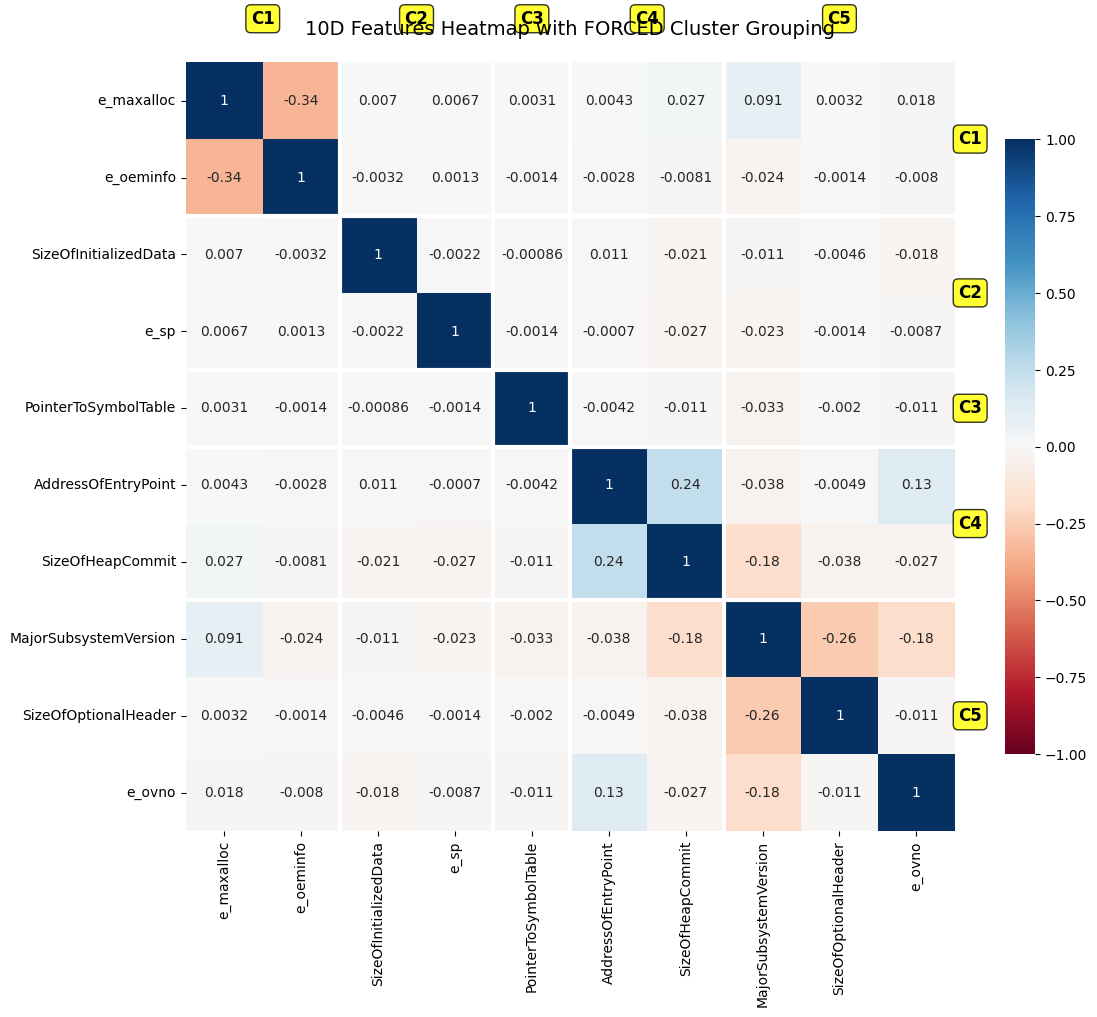


10D Features FORCED Clustering Summary:
Ordered features (grouped by cluster): ['e_maxalloc', 'e_oeminfo', 'SizeOfInitializedData', 'e_sp', 'PointerToSymbolTable', 'AddressOfEntryPoint', 'SizeOfHeapCommit', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'e_ovno']

FORCED Cluster Summary for 10D:
Features are GUARANTEED to be grouped by cluster (no dendrogram reordering)
Ordered features: ['e_maxalloc', 'e_oeminfo', 'SizeOfInitializedData', 'e_sp', 'PointerToSymbolTable', 'AddressOfEntryPoint', 'SizeOfHeapCommit', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'e_ovno']

Cluster groups (in matrix order):
Cluster 1 (2 features): ['e_maxalloc', 'e_oeminfo']
Cluster 2 (2 features): ['SizeOfInitializedData', 'e_sp']
Cluster 3 (1 features): ['PointerToSymbolTable']
Cluster 4 (2 features): ['AddressOfEntryPoint', 'SizeOfHeapCommit']
Cluster 5 (3 features): ['MajorSubsystemVersion', 'SizeOfOptionalHeader', 'e_ovno']
FORCED grouping: Features ordered by clusters
  Cluster 1: ['e_maxalloc',

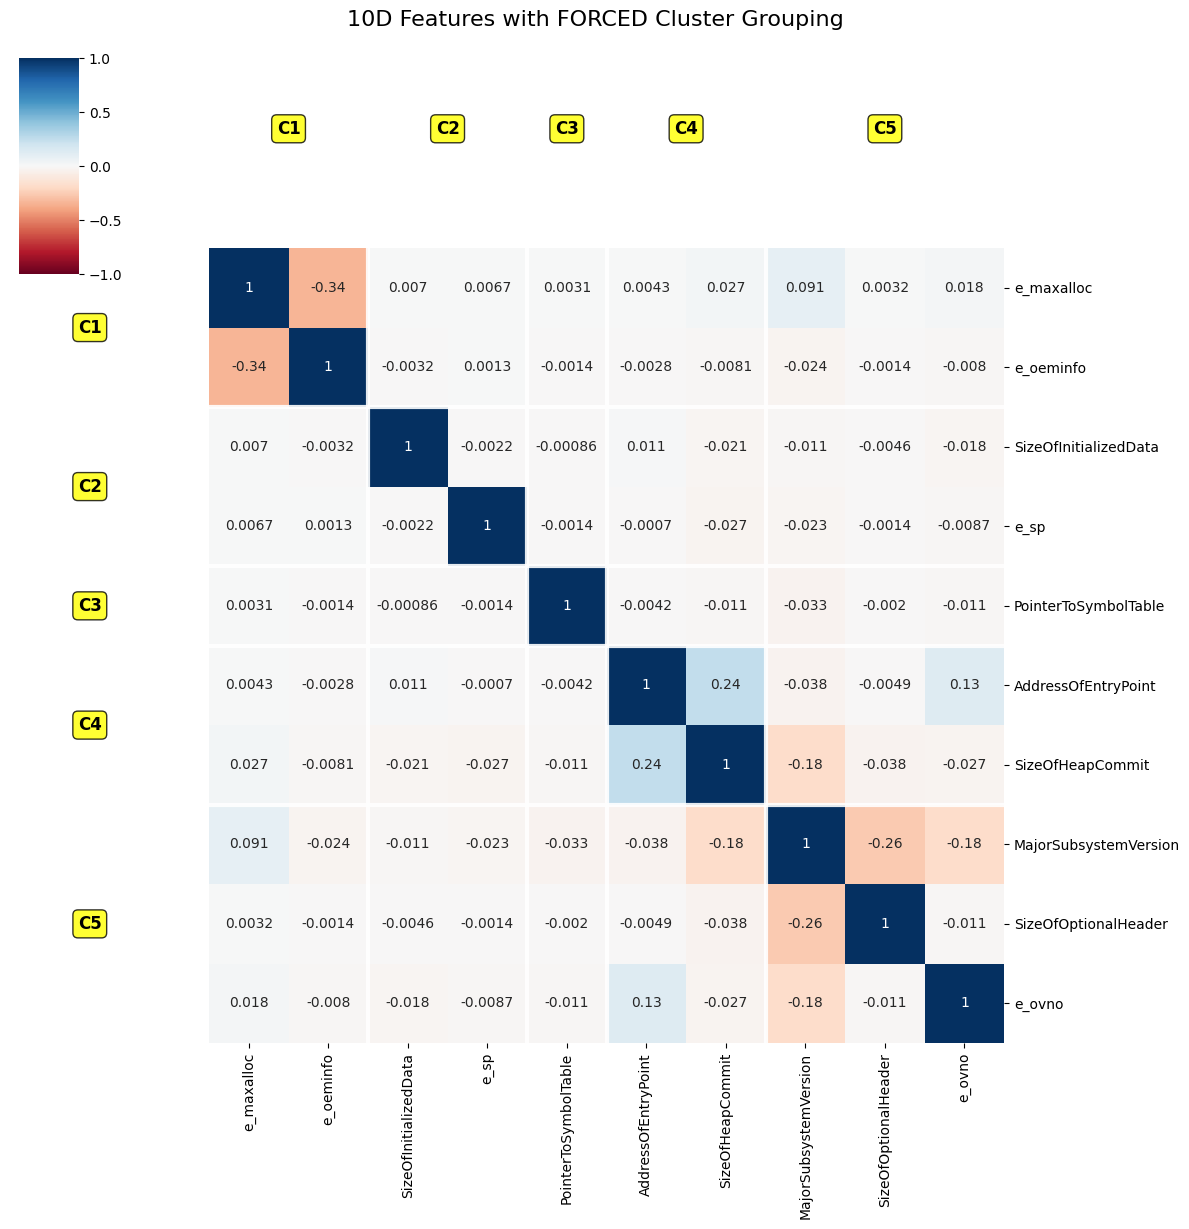


FORCED Cluster Summary for 10D:
Features are GUARANTEED to be grouped by cluster (no dendrogram reordering)
Ordered features: ['e_maxalloc', 'e_oeminfo', 'SizeOfInitializedData', 'e_sp', 'PointerToSymbolTable', 'AddressOfEntryPoint', 'SizeOfHeapCommit', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'e_ovno']

Cluster groups (in matrix order):
Cluster 1 (2 features): ['e_maxalloc', 'e_oeminfo']
Cluster 2 (2 features): ['SizeOfInitializedData', 'e_sp']
Cluster 3 (1 features): ['PointerToSymbolTable']
Cluster 4 (2 features): ['AddressOfEntryPoint', 'SizeOfHeapCommit']
Cluster 5 (3 features): ['MajorSubsystemVersion', 'SizeOfOptionalHeader', 'e_ovno']
Selected 10 features for 10D visualization:
Using feature_2to10[8]: ['e_ovno', 'e_maxalloc', 'e_sp', 'e_oeminfo', 'PointerToSymbolTable', 'SizeOfOptionalHeader', 'SizeOfInitializedData', 'AddressOfEntryPoint', 'MajorSubsystemVersion', 'SizeOfHeapCommit']
FORCED grouping: Features ordered by clusters
  Cluster 1: ['e_maxalloc', 'e_oeminfo'

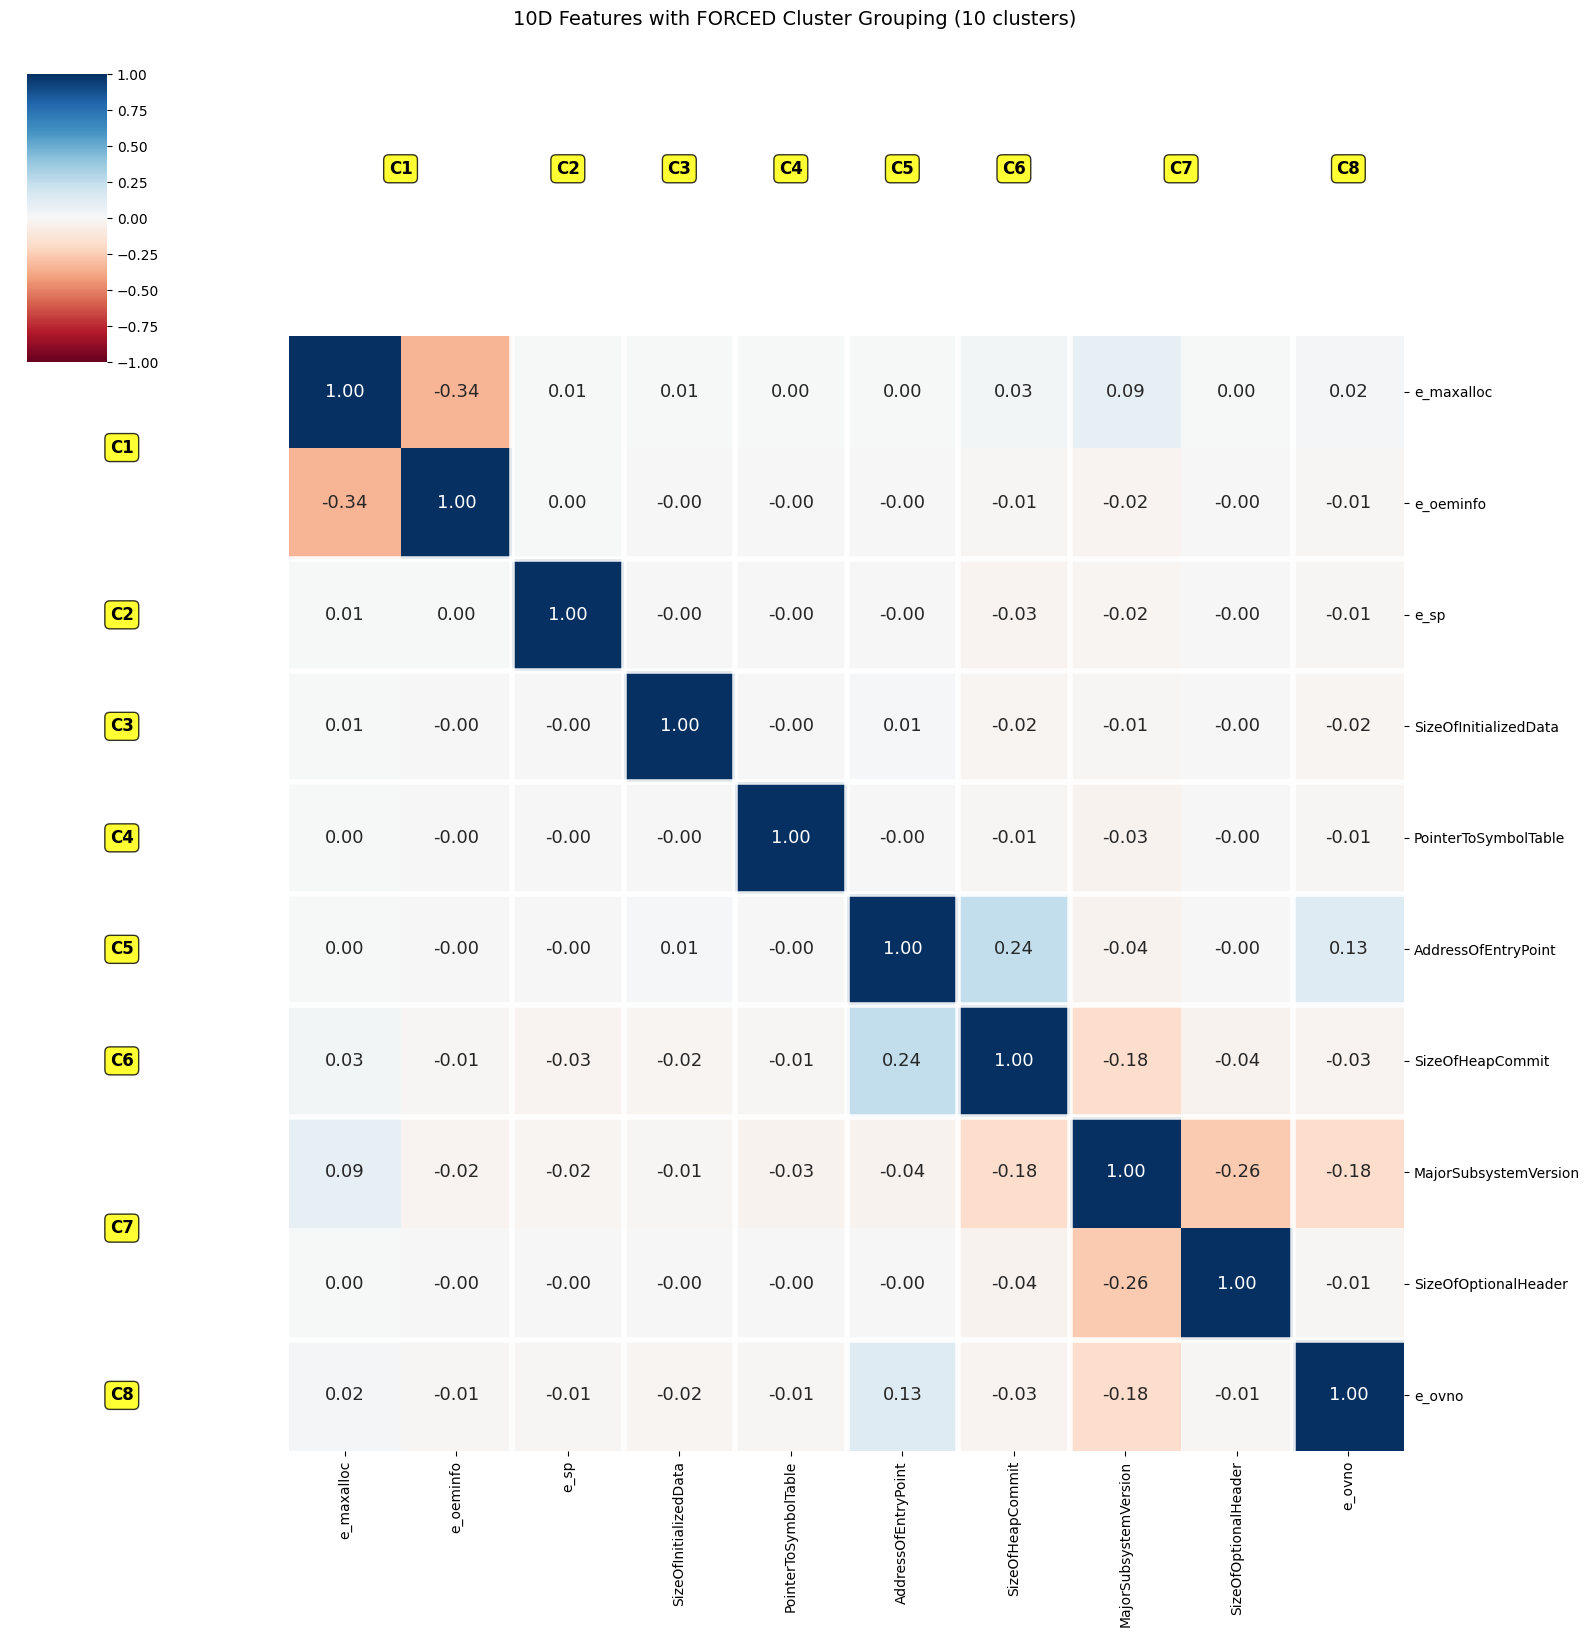


FORCED Cluster Summary for 10:
Features are GUARANTEED to be grouped by cluster (no dendrogram reordering)
Ordered features: ['e_maxalloc', 'e_oeminfo', 'e_sp', 'SizeOfInitializedData', 'PointerToSymbolTable', 'AddressOfEntryPoint', 'SizeOfHeapCommit', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'e_ovno']

Cluster groups (in matrix order):
Cluster 1 (2 features): ['e_maxalloc', 'e_oeminfo']
Cluster 2 (1 features): ['e_sp']
Cluster 3 (1 features): ['SizeOfInitializedData']
Cluster 4 (1 features): ['PointerToSymbolTable']
Cluster 5 (1 features): ['AddressOfEntryPoint']
Cluster 6 (1 features): ['SizeOfHeapCommit']
Cluster 7 (2 features): ['MajorSubsystemVersion', 'SizeOfOptionalHeader']
Cluster 8 (1 features): ['e_ovno']


In [72]:
processor = MinimalDataProcessor(
    dataset_path=dataset_path,
    target_col='class'
)
feature_2to10 = processor.run_all()
feature_2to10 = feature_2to10[:9]
# Get specific features
# features_5d = processor.get_features(5)
# subset_data = processor.get_subset(5, include_target=True)

### Kernel plot

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split

def classical_kernel_plot(feature_2to10, df, y):
    """
    Plot classical RBF kernel matrices (training and testing) in green colormap
    
    Parameters:
    -----------
    feature_2to10 : list
        List of feature lists from hierarchical clustering
    df : pd.DataFrame
        Full dataframe with all features
    y : pd.Series or array-like
        Target labels
    """
    # Get first 2 features from hierarchical clustering
    features_2d = feature_2to10[0]  # First entry has 2 features
    print(f"Using 2D features from hierarchical clustering: {features_2d}")
    
    # Extract the 2 features
    X = df[features_2d].values
    
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Sort by labels: all class 0 first, then all class 1
    train_sort_idx = np.argsort(y_train)
    X_train = X_train[train_sort_idx]
    y_train = y_train.iloc[train_sort_idx] if hasattr(y_train, 'iloc') else y_train[train_sort_idx]
    
    test_sort_idx = np.argsort(y_test)
    X_test = X_test[test_sort_idx]
    y_test = y_test.iloc[test_sort_idx] if hasattr(y_test, 'iloc') else y_test[test_sort_idx]
    
    # Compute classical RBF kernel matrices
    print("Computing classical RBF kernel matrices...")
    classical_kernel_train = rbf_kernel(X_train, X_train)
    classical_kernel_test = rbf_kernel(X_test, X_train)
    
    # Create plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Training kernel matrix (Green)
    im1 = axs[0].imshow(
        np.asmatrix(classical_kernel_train), 
        interpolation="nearest", 
        origin="upper", 
        cmap="Greens",
        vmin=0, 
        vmax=1
    )
    axs[0].set_title(f"Classical RBF Training Kernel Matrix\n({features_2d[0]} & {features_2d[1]})", 
                     fontsize=12, fontweight='bold')
    axs[0].set_xlabel("Training Sample Index", fontsize=10)
    axs[0].set_ylabel("Training Sample Index", fontsize=10)
    cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Kernel Similarity', fontsize=10)
    
    # Testing kernel matrix (Light Green)
    im2 = axs[1].imshow(
        np.asmatrix(classical_kernel_test), 
        interpolation="nearest", 
        origin="upper", 
        cmap="YlGn",  # Yellow-Green for differentiation
        vmin=0, 
        vmax=1
    )
    axs[1].set_title(f"Classical RBF Testing Kernel Matrix\n({features_2d[0]} & {features_2d[1]})", 
                     fontsize=12, fontweight='bold')
    axs[1].set_xlabel("Training Sample Index", fontsize=10)
    axs[1].set_ylabel("Testing Sample Index", fontsize=10)
    cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Kernel Similarity', fontsize=10)
    

    
    plt.suptitle('Classical RBF Kernel Matrices (First 2 Features from Hierarchical Clustering)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("CLASSICAL RBF KERNEL SUMMARY")
    print("="*70)
    print(f"Features: {features_2d}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"\nTraining kernel matrix shape: {classical_kernel_train.shape}")
    print(f"  Mean similarity: {np.mean(classical_kernel_train):.4f}")
    print(f"  Std similarity: {np.std(classical_kernel_train):.4f}")
    print(f"  Min similarity: {np.min(classical_kernel_train):.4f}")
    print(f"  Max similarity: {np.max(classical_kernel_train):.4f}")
    print(f"\nTesting kernel matrix shape: {classical_kernel_test.shape}")
    print(f"  Mean similarity: {np.mean(classical_kernel_test):.4f}")
    print(f"  Std similarity: {np.std(classical_kernel_test):.4f}")
    print(f"  Min similarity: {np.min(classical_kernel_test):.4f}")
    print(f"  Max similarity: {np.max(classical_kernel_test):.4f}")
    print("="*70)
    
    return classical_kernel_train, classical_kernel_test


def quantum_kernel_plot(feature_2to10, df, y):
    """
    Plot quantum ZZFeatureMap kernel matrices (training and testing) in green colormap
    
    Parameters:
    -----------
    feature_2to10 : list
        List of feature lists from hierarchical clustering
    df : pd.DataFrame
        Full dataframe with all features
    y : pd.Series or array-like
        Target labels
    """
    # Get first 2 features from hierarchical clustering
    features_2d = feature_2to10[0]  # First entry has 2 features
    print(f"Using 2D features from hierarchical clustering: {features_2d}")
    
    # Extract the 2 features
    X = df[features_2d].values
    
    # Normalize features for quantum encoding [0, π]
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X)
    
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Create quantum kernel with ZZFeatureMap
    print("Creating quantum ZZFeatureMap kernel...")
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
    
    # Compute quantum kernel matrices
    print("Computing quantum kernel matrices...")
    quantum_kernel_train = quantum_kernel.evaluate(x_vec=X_train)
    quantum_kernel_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)
    
    # Create plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Training kernel matrix (Dark Green)
    im1 = axs[0].imshow(
        np.asmatrix(quantum_kernel_train), 
        interpolation="nearest", 
        origin="upper", 
        cmap="Greens",
        vmin=0, 
        vmax=1
    )
    axs[0].set_title(f"Quantum ZZFeatureMap Training Kernel Matrix\n({features_2d[0]} & {features_2d[1]})", 
                     fontsize=12, fontweight='bold')
    axs[0].set_xlabel("Training Sample Index", fontsize=10)
    axs[0].set_ylabel("Training Sample Index", fontsize=10)
    cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Quantum Similarity', fontsize=10)
    
    # Testing kernel matrix (Light Green)
    im2 = axs[1].imshow(
        np.asmatrix(quantum_kernel_test), 
        interpolation="nearest", 
        origin="upper", 
        cmap="YlGn",  # Yellow-Green for differentiation
        vmin=0, 
        vmax=1
    )
    axs[1].set_title(f"Quantum ZZFeatureMap Testing Kernel Matrix\n({features_2d[0]} & {features_2d[1]})", 
                     fontsize=12, fontweight='bold')
    axs[1].set_xlabel("Training Sample Index", fontsize=10)
    axs[1].set_ylabel("Testing Sample Index", fontsize=10)
    cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Quantum Similarity', fontsize=10)
    

    
    plt.suptitle('Quantum ZZFeatureMap Kernel Matrices (First 2 Features from Hierarchical Clustering)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("QUANTUM ZZFEATUREMAP KERNEL SUMMARY")
    print("="*70)
    print(f"Features: {features_2d}")
    print(f"Feature map: ZZFeatureMap (2 qubits, 2 reps)")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"\nTraining kernel matrix shape: {quantum_kernel_train.shape}")
    print(f"  Mean similarity: {np.mean(quantum_kernel_train):.4f}")
    print(f"  Std similarity: {np.std(quantum_kernel_train):.4f}")
    print(f"  Min similarity: {np.min(quantum_kernel_train):.4f}")
    print(f"  Max similarity: {np.max(quantum_kernel_train):.4f}")
    print(f"\nTesting kernel matrix shape: {quantum_kernel_test.shape}")
    print(f"  Mean similarity: {np.mean(quantum_kernel_test):.4f}")
    print(f"  Std similarity: {np.std(quantum_kernel_test):.4f}")
    print(f"  Min similarity: {np.min(quantum_kernel_test):.4f}")
    print(f"  Max similarity: {np.max(quantum_kernel_test):.4f}")
    print("="*70)
    
    return quantum_kernel_train, quantum_kernel_test


# Combined comparison function
def compare_classical_quantum_kernels(feature_2to10, df, y):
    """
    Create side-by-side comparison of classical and quantum kernels
    
    Parameters:
    -----------
    feature_2to10 : list
        List of feature lists from hierarchical clustering
    df : pd.DataFrame
        Full dataframe with all features
    y : pd.Series or array-like
        Target labels
    """
    # Get first 2 features
    features_2d = feature_2to10[0]
    print(f"Comparing kernels using: {features_2d}")
    
    X = df[features_2d].values
    
    # For quantum: normalize to [0, π]
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_quantum = scaler.fit_transform(X)
    
    # Split data
    X_train_classical, X_test_classical, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_train_quantum, X_test_quantum = train_test_split(
        X_quantum, test_size=0.3, random_state=42, stratify=y
    )[0:2]
    
    # Compute classical kernels
    print("Computing classical RBF kernels...")
    classical_train = rbf_kernel(X_train_classical, X_train_classical)
    classical_test = rbf_kernel(X_test_classical, X_train_classical)
    
    # Compute quantum kernels
    print("Computing quantum ZZFeatureMap kernels...")
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
    quantum_train = quantum_kernel.evaluate(x_vec=X_train_quantum)
    quantum_test = quantum_kernel.evaluate(x_vec=X_test_quantum, y_vec=X_train_quantum)
    
    # Create comprehensive comparison plot
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    
    # Classical Training
    im1 = axs[0, 0].imshow(classical_train, interpolation="nearest", 
                           origin="upper", cmap="Greens", vmin=0, vmax=1)
    axs[0, 0].set_title("Classical RBF Training Kernel", fontweight='bold')
    axs[0, 0].set_xlabel("Training Index")
    axs[0, 0].set_ylabel("Training Index")
    plt.colorbar(im1, ax=axs[0, 0], fraction=0.046, pad=0.04)
    
    # Classical Testing
    im2 = axs[0, 1].imshow(classical_test, interpolation="nearest", 
                           origin="upper", cmap="YlGn", vmin=0, vmax=1)
    axs[0, 1].set_title("Classical RBF Testing Kernel", fontweight='bold')
    axs[0, 1].set_xlabel("Training Index")
    axs[0, 1].set_ylabel("Testing Index")
    plt.colorbar(im2, ax=axs[0, 1], fraction=0.046, pad=0.04)
    
    # Quantum Training
    im3 = axs[1, 0].imshow(quantum_train, interpolation="nearest", 
                           origin="upper", cmap="Greens", vmin=0, vmax=1)
    axs[1, 0].set_title("Quantum ZZFeatureMap Training Kernel", fontweight='bold')
    axs[1, 0].set_xlabel("Training Index")
    axs[1, 0].set_ylabel("Training Index")
    plt.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04)
    
    # Quantum Testing
    im4 = axs[1, 1].imshow(quantum_test, interpolation="nearest", 
                           origin="upper", cmap="YlGn", vmin=0, vmax=1)
    axs[1, 1].set_title("Quantum ZZFeatureMap Testing Kernel", fontweight='bold')
    axs[1, 1].set_xlabel("Training Index")
    axs[1, 1].set_ylabel("Testing Index")
    plt.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04)
    
    plt.suptitle(f'Classical vs Quantum Kernel Comparison\nFeatures: {features_2d[0]} & {features_2d[1]}',
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print("\n" + "="*70)
    print("CLASSICAL VS QUANTUM KERNEL COMPARISON")
    print("="*70)
    print(f"Features: {features_2d}")
    print(f"\n{'Metric':<30} {'Classical':<20} {'Quantum':<20}")
    print("-" * 70)
    print(f"{'Train mean similarity':<30} {np.mean(classical_train):<20.4f} {np.mean(quantum_train):<20.4f}")
    print(f"{'Train std similarity':<30} {np.std(classical_train):<20.4f} {np.std(quantum_train):<20.4f}")
    print(f"{'Test mean similarity':<30} {np.mean(classical_test):<20.4f} {np.mean(quantum_test):<20.4f}")
    print(f"{'Test std similarity':<30} {np.std(classical_test):<20.4f} {np.std(quantum_test):<20.4f}")
    print("="*70)


# Example usage:
"""
# Process data
processor = MinimalDataProcessor(dataset_path="/path/to/dataset")
feature_2to10 = processor.run_all(plotd=10)
df = processor.df
y = df['class']

# Plot classical kernel matrices (green)
classical_kernel_plot(feature_2to10, df, y)

# Plot quantum kernel matrices (green)
quantum_kernel_plot(feature_2to10, df, y)

# Or compare both at once
compare_classical_quantum_kernels(feature_2to10, df, y)
"""

'\n# Process data\nprocessor = MinimalDataProcessor(dataset_path="/path/to/dataset")\nfeature_2to10 = processor.run_all(plotd=10)\ndf = processor.df\ny = df[\'class\']\n\n# Plot classical kernel matrices (green)\nclassical_kernel_plot(feature_2to10, df, y)\n\n# Plot quantum kernel matrices (green)\nquantum_kernel_plot(feature_2to10, df, y)\n\n# Or compare both at once\ncompare_classical_quantum_kernels(feature_2to10, df, y)\n'

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split

def kernel(type="classical", feature_2to10=None, df=None, y=None):
    """
    Unified function to run classical or quantum kernel with y=0 samples in front and y=1 in back
    
    Parameters:
    -----------
    type : str
        "classical" for classical RBF kernel, "quantum" for quantum ZZFeatureMap kernel
    feature_2to10 : list
        List of feature lists from hierarchical clustering
    df : pd.DataFrame
        Full dataframe with all features
    y : pd.Series or array-like
        Target labels
    """
    if feature_2to10 is None or df is None or y is None:
        raise ValueError("feature_2to10, df, and y must be provided")
    
    # Get first 2 features from hierarchical clustering
    features_2d = feature_2to10[0]  # First entry has 2 features
    print(f"Using 2D features from hierarchical clustering: {features_2d}")
    
    # Extract the 2 features
    X = df[features_2d].values
    
    # Convert y to numpy array
    y_array = y.values if hasattr(y, 'values') else np.array(y)
    
    # Get indices for class 0 and class 1
    class_0_idx = np.where(y_array == 0)[0]
    class_1_idx = np.where(y_array == 1)[0]
    
    # Calculate 50% of dataset (25% from each class)
    n_samples_per_class = int(len(df) * 0.25)
    
    np.random.seed(42)
    sampled_0_idx = np.random.choice(class_0_idx, size=min(n_samples_per_class, len(class_0_idx)), replace=False)
    sampled_1_idx = np.random.choice(class_1_idx, size=min(n_samples_per_class, len(class_1_idx)), replace=False)
    
    # Combine indices with class 0 first, then class 1
    sampled_idx = np.concatenate([sampled_0_idx, sampled_1_idx])
    X_sampled = X[sampled_idx]
    y_sampled = y_array[sampled_idx]
    
    print(f"Sampled {len(X_sampled)} total samples: {np.sum(y_sampled==0)} class 0, {np.sum(y_sampled==1)} class 1")
    
    if type == "classical":
        return _run_classical_kernel(X_sampled, y_sampled, features_2d)
    elif type == "quantum":
        return _run_quantum_kernel(X_sampled, y_sampled, features_2d)
    else:
        raise ValueError("type must be 'classical' or 'quantum'")

def _run_classical_kernel(X_sampled, y_sampled, features_2d):
    """Run classical RBF kernel with proper ordering"""
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X_sampled, y_sampled, test_size=0.3, random_state=42, stratify=y_sampled
    )
    
    # Sort by labels: all class 0 first, then all class 1
    train_sort_idx = np.argsort(y_train)
    X_train = X_train[train_sort_idx]
    y_train = y_train[train_sort_idx]
    
    test_sort_idx = np.argsort(y_test)
    X_test = X_test[test_sort_idx]
    y_test = y_test[test_sort_idx]
    
    # Compute classical RBF kernel matrices
    print("Computing classical RBF kernel matrices...")
    classical_kernel_train = rbf_kernel(X_train, X_train)
    classical_kernel_test = rbf_kernel(X_test, X_train)
    
    # Create plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Training kernel matrix (Green)
    im1 = axs[0].imshow(
        np.asmatrix(classical_kernel_train), 
        interpolation="nearest", 
        origin="upper", 
        cmap="Greens",
        vmin=0, 
        vmax=1
    )
    axs[0].set_title(f"Classical RBF training kernel matrix", fontsize=10)
    axs[0].set_xlabel("Training sample index", fontsize=8)
    axs[0].set_ylabel("Training sample index", fontsize=8)
    axs[0].tick_params(labelsize=7)
    cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Kernel similarity', fontsize=8)
    cbar1.ax.tick_params(labelsize=7)
    
    # Testing kernel matrix (Light Green)
    im2 = axs[1].imshow(
        np.asmatrix(classical_kernel_test), 
        interpolation="nearest", 
        origin="upper", 
        cmap="YlGn",
        vmin=0, 
        vmax=1
    )
    axs[1].set_title(f"Classical RBF testing kernel matrix", fontsize=10)
    axs[1].set_xlabel("Training sample index", fontsize=8)
    axs[1].set_ylabel("Testing sample index", fontsize=8)
    axs[1].tick_params(labelsize=7)
    cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Kernel similarity', fontsize=8)
    cbar2.ax.tick_params(labelsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("CLASSICAL RBF KERNEL SUMMARY")
    print("="*70)
    print(f"Features: {features_2d}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"\nTraining kernel matrix shape: {classical_kernel_train.shape}")
    print(f"  Mean similarity: {np.mean(classical_kernel_train):.4f}")
    print(f"  Std similarity: {np.std(classical_kernel_train):.4f}")
    print(f"  Min similarity: {np.min(classical_kernel_train):.4f}")
    print(f"  Max similarity: {np.max(classical_kernel_train):.4f}")
    print(f"\nTesting kernel matrix shape: {classical_kernel_test.shape}")
    print(f"  Mean similarity: {np.mean(classical_kernel_test):.4f}")
    print(f"  Std similarity: {np.std(classical_kernel_test):.4f}")
    print(f"  Min similarity: {np.min(classical_kernel_test):.4f}")
    print(f"  Max similarity: {np.max(classical_kernel_test):.4f}")
    print("="*70)
    
    return classical_kernel_train, classical_kernel_test

def _run_quantum_kernel(X_sampled, y_sampled, features_2d):
    """Run quantum kernel with proper ordering"""
    # Normalize features for quantum encoding [0, π]
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_sampled)
    
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_sampled, test_size=0.3, random_state=42, stratify=y_sampled
    )
    
    # Sort by labels: all class 0 first, then all class 1
    train_sort_idx = np.argsort(y_train)
    X_train = X_train[train_sort_idx]
    y_train = y_train[train_sort_idx]
    
    test_sort_idx = np.argsort(y_test)
    X_test = X_test[test_sort_idx]
    y_test = y_test[test_sort_idx]
    
    # Create quantum kernel with ZZFeatureMap
    print("Creating quantum ZZFeatureMap kernel...")
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
    
    # Compute quantum kernel matrices
    print("Computing quantum kernel matrices...")
    quantum_kernel_train = quantum_kernel.evaluate(x_vec=X_train)
    quantum_kernel_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)
    
    # Create plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Training kernel matrix (Dark Green)
    im1 = axs[0].imshow(
        np.asmatrix(quantum_kernel_train), 
        interpolation="nearest", 
        origin="upper", 
        cmap="Greens",
        vmin=0, 
        vmax=1
    )
    axs[0].set_title(f"Quantum training kernel matrix", fontsize=10)
    axs[0].set_xlabel("Training sample index", fontsize=8)
    axs[0].set_ylabel("Training sample index", fontsize=8)
    axs[0].tick_params(labelsize=7)
    cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Quantum similarity', fontsize=8)
    cbar1.ax.tick_params(labelsize=7)
    
    # Testing kernel matrix (Light Green)
    im2 = axs[1].imshow(
        np.asmatrix(quantum_kernel_test), 
        interpolation="nearest", 
        origin="upper", 
        cmap="YlGn",
        vmin=0, 
        vmax=1
    )
    axs[1].set_title(f"Quantum testing kernel matrix", fontsize=10)
    axs[1].set_xlabel("Training sample index", fontsize=8)
    axs[1].set_ylabel("Testing sample index", fontsize=8)
    axs[1].tick_params(labelsize=7)
    cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Quantum similarity', fontsize=8)
    cbar2.ax.tick_params(labelsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("QUANTUM ZZFEATUREMAP KERNEL SUMMARY")
    print("="*70)
    print(f"Features: {features_2d}")
    print(f"Feature map: ZZFeatureMap (2 qubits, 2 reps)")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"\nTraining kernel matrix shape: {quantum_kernel_train.shape}")
    print(f"  Mean similarity: {np.mean(quantum_kernel_train):.4f}")
    print(f"  Std similarity: {np.std(quantum_kernel_train):.4f}")
    print(f"  Min similarity: {np.min(quantum_kernel_train):.4f}")
    print(f"  Max similarity: {np.max(quantum_kernel_train):.4f}")
    print(f"\nTesting kernel matrix shape: {quantum_kernel_test.shape}")
    print(f"  Mean similarity: {np.mean(quantum_kernel_test):.4f}")
    print(f"  Std similarity: {np.std(quantum_kernel_test):.4f}")
    print(f"  Min similarity: {np.min(quantum_kernel_test):.4f}")
    print(f"  Max similarity: {np.max(quantum_kernel_test):.4f}")
    print("="*70)
    
    return quantum_kernel_train, quantum_kernel_test

# Example usage:
"""
# Process data
processor = MinimalDataProcessor(dataset_path="/path/to/dataset")
feature_2to10 = processor.run_all(plotd=10)
df = processor.df
y = df['class']

# Run classical kernel
classical_train, classical_test = kernel(type="classical", feature_2to10=feature_2to10, df=df, y=y)

# Run quantum kernel  
quantum_train, quantum_test = kernel(type="quantum", feature_2to10=feature_2to10, df=df, y=y)
"""

'\n# Process data\nprocessor = MinimalDataProcessor(dataset_path="/path/to/dataset")\nfeature_2to10 = processor.run_all(plotd=10)\ndf = processor.df\ny = df[\'class\']\n\n# Run classical kernel\nclassical_train, classical_test = kernel(type="classical", feature_2to10=feature_2to10, df=df, y=y)\n\n# Run quantum kernel  \nquantum_train, quantum_test = kernel(type="quantum", feature_2to10=feature_2to10, df=df, y=y)\n'

Using 2D features from hierarchical clustering: ['e_cblp', 'SizeOfCode']
Sampled 500 total samples: 250 class 0, 250 class 1
Computing classical RBF kernel matrices...


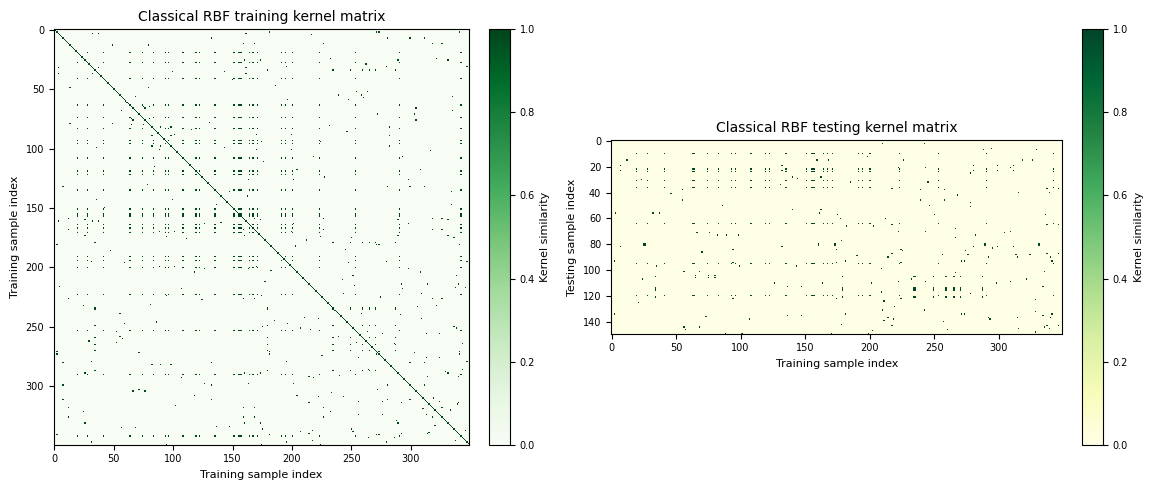


CLASSICAL RBF KERNEL SUMMARY
Features: ['e_cblp', 'SizeOfCode']
Training samples: 350
Testing samples: 150

Training kernel matrix shape: (350, 350)
  Mean similarity: 0.0121
  Std similarity: 0.1092
  Min similarity: 0.0000
  Max similarity: 1.0000

Testing kernel matrix shape: (150, 350)
  Mean similarity: 0.0088
  Std similarity: 0.0933
  Min similarity: 0.0000
  Max similarity: 1.0000
Using 2D features from hierarchical clustering: ['e_cblp', 'SizeOfCode']
Sampled 500 total samples: 250 class 0, 250 class 1
Creating quantum ZZFeatureMap kernel...
Computing quantum kernel matrices...


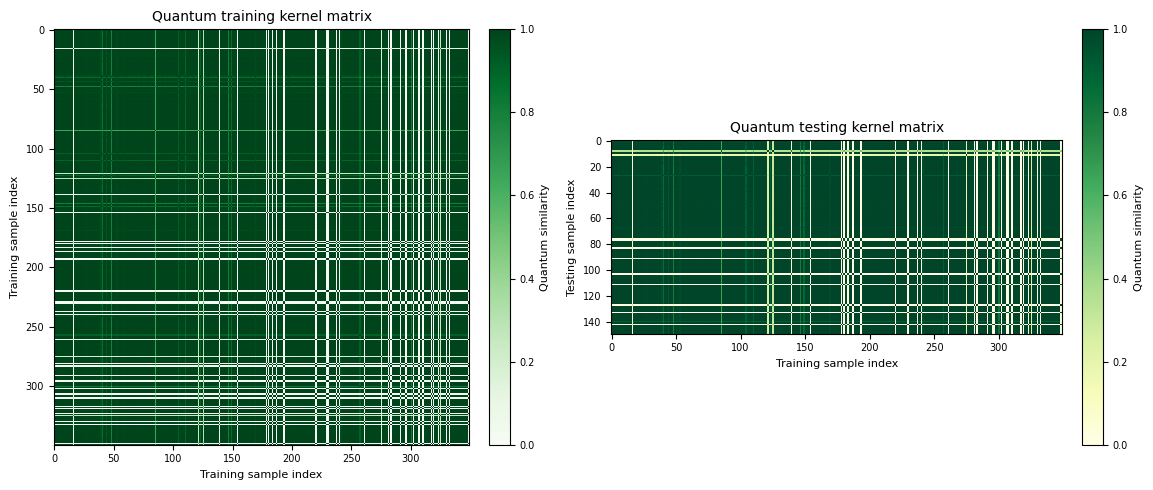


QUANTUM ZZFEATUREMAP KERNEL SUMMARY
Features: ['e_cblp', 'SizeOfCode']
Feature map: ZZFeatureMap (2 qubits, 2 reps)
Training samples: 350
Testing samples: 150

Training kernel matrix shape: (350, 350)
  Mean similarity: 0.8242
  Std similarity: 0.3606
  Min similarity: 0.0009
  Max similarity: 1.0000

Testing kernel matrix shape: (150, 350)
  Mean similarity: 0.8447
  Std similarity: 0.3447
  Min similarity: 0.0009
  Max similarity: 1.0000


In [55]:
# processor = MinimalDataProcessor(dataset_path="/path/to/dataset")
# feature_2to10 = processor.run_all(plotd=10)
df = processor.df
y = df['class']

# Run classical kernel
classical_train, classical_test = kernel(type="classical", feature_2to10=feature_2to10, df=df, y=y)

# Run quantum kernel  
quantum_train, quantum_test = kernel(type="quantum", feature_2to10=feature_2to10, df=df, y=y)


In [75]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split

def kernel(type="classical", feature_2to10=None, df=None, y=None):
    """
    Unified function to run classical or quantum kernel with y=0 samples in front and y=1 in back
    
    Parameters:
    -----------
    type : str
        "classical" for classical RBF kernel, "quantum" for quantum ZZFeatureMap kernel
    feature_2to10 : list
        List of feature lists from hierarchical clustering
    df : pd.DataFrame
        Full dataframe with all features
    y : pd.Series or array-like
        Target labels
    """
    if feature_2to10 is None or df is None or y is None:
        raise ValueError("feature_2to10, df, and y must be provided")
    
    # Get first 2 features from hierarchical clustering
    features_2d = feature_2to10[0]  # First entry has 2 features
    print(f"Using 2D features from hierarchical clustering: {features_2d}")
    
    # Extract the 2 features
    X = df[features_2d].values
    
    # Convert y to numpy array
    y_array = y.values if hasattr(y, 'values') else np.array(y)
    
    # Get indices for class 0 and class 1
    class_0_idx = np.where(y_array == 0)[0]
    class_1_idx = np.where(y_array == 1)[0]
    
    # Calculate 50% of dataset (25% from each class)
    n_samples_per_class = int(len(df) * 0.25)
    
    np.random.seed(42)
    sampled_0_idx = np.random.choice(class_0_idx, size=min(n_samples_per_class, len(class_0_idx)), replace=False)
    sampled_1_idx = np.random.choice(class_1_idx, size=min(n_samples_per_class, len(class_1_idx)), replace=False)
    
    # Combine indices with class 0 first, then class 1
    sampled_idx = np.concatenate([sampled_0_idx, sampled_1_idx])
    X_sampled = X[sampled_idx]
    y_sampled = y_array[sampled_idx]
    
    print(f"Sampled {len(X_sampled)} total samples: {np.sum(y_sampled==0)} class 0, {np.sum(y_sampled==1)} class 1")
    
    if type == "classical":
        return _run_classical_kernel(X_sampled, y_sampled, features_2d)
    elif type == "quantum":
        return _run_quantum_kernel(X_sampled, y_sampled, features_2d)
    else:
        raise ValueError("type must be 'classical' or 'quantum'")

def _run_classical_kernel(X_sampled, y_sampled, features_2d):
    """Run classical RBF kernel with proper ordering"""
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X_sampled, y_sampled, test_size=0.3, random_state=42, stratify=y_sampled
    )
    
    # Sort by labels: all class 0 first, then all class 1
    train_sort_idx = np.argsort(y_train)
    X_train = X_train[train_sort_idx]
    y_train = y_train[train_sort_idx]
    
    test_sort_idx = np.argsort(y_test)
    X_test = X_test[test_sort_idx]
    y_test = y_test[test_sort_idx]
    
    # Compute classical RBF kernel matrices
    print("Computing classical RBF kernel matrices...")
    classical_kernel_train = rbf_kernel(X_train, X_train)
    classical_kernel_test = rbf_kernel(X_test, X_train)
    
    # Create plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Training kernel matrix (Green)
    im1 = axs[0].imshow(
        np.asmatrix(classical_kernel_train), 
        interpolation="nearest", 
        origin="upper", 
        cmap="Greens",
        vmin=0, 
        vmax=1
    )
    axs[0].set_title(f"Classical RBF training kernel matrix", fontsize=10)
    axs[0].set_xlabel("Training sample index", fontsize=8)
    axs[0].set_ylabel("Training sample index", fontsize=8)
    axs[0].tick_params(labelsize=7)
    cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Kernel similarity', fontsize=8)
    cbar1.ax.tick_params(labelsize=7)
    
    # Testing kernel matrix (Light Green)
    im2 = axs[1].imshow(
        np.asmatrix(classical_kernel_test), 
        interpolation="nearest", 
        origin="upper", 
        cmap="YlGn",
        vmin=0, 
        vmax=1
    )
    axs[1].set_title(f"Classical RBF testing kernel matrix", fontsize=10)
    axs[1].set_xlabel("Training sample index", fontsize=8)
    axs[1].set_ylabel("Testing sample index", fontsize=8)
    axs[1].tick_params(labelsize=7)
    cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Kernel similarity', fontsize=8)
    cbar2.ax.tick_params(labelsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("CLASSICAL RBF KERNEL SUMMARY")
    print("="*70)
    print(f"Features: {features_2d}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"\nTraining kernel matrix shape: {classical_kernel_train.shape}")
    print(f"  Mean similarity: {np.mean(classical_kernel_train):.4f}")
    print(f"  Std similarity: {np.std(classical_kernel_train):.4f}")
    print(f"  Min similarity: {np.min(classical_kernel_train):.4f}")
    print(f"  Max similarity: {np.max(classical_kernel_train):.4f}")
    print(f"\nTesting kernel matrix shape: {classical_kernel_test.shape}")
    print(f"  Mean similarity: {np.mean(classical_kernel_test):.4f}")
    print(f"  Std similarity: {np.std(classical_kernel_test):.4f}")
    print(f"  Min similarity: {np.min(classical_kernel_test):.4f}")
    print(f"  Max similarity: {np.max(classical_kernel_test):.4f}")
    print("="*70)
    
    return classical_kernel_train, classical_kernel_test

def _run_quantum_kernel(X_sampled, y_sampled, features_2d):
    """Run quantum kernel with proper ordering"""
    # Normalize features for quantum encoding [0, π]
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_sampled)
    
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_sampled, test_size=0.3, random_state=42, stratify=y_sampled
    )
    
    # Sort by labels: all class 0 first, then all class 1
    train_sort_idx = np.argsort(y_train)
    X_train = X_train[train_sort_idx]
    y_train = y_train[train_sort_idx]
    
    test_sort_idx = np.argsort(y_test)
    X_test = X_test[test_sort_idx]
    y_test = y_test[test_sort_idx]
    
    # Create quantum kernel with ZZFeatureMap
    print("Creating quantum ZZFeatureMap kernel...")
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
    
    # Compute quantum kernel matrices
    print("Computing quantum kernel matrices...")
    quantum_kernel_train = quantum_kernel.evaluate(x_vec=X_train)
    quantum_kernel_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)
    
    # Create plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Training kernel matrix (Dark Green)
    im1 = axs[0].imshow(
        np.asmatrix(quantum_kernel_train), 
        interpolation="nearest", 
        origin="upper", 
        cmap="Greens",
        vmin=0, 
        vmax=1
    )
    axs[0].set_title(f"Quantum training kernel matrix", fontsize=10)
    axs[0].set_xlabel("Training sample index", fontsize=8)
    axs[0].set_ylabel("Training sample index", fontsize=8)
    axs[0].tick_params(labelsize=7)
    cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Quantum similarity', fontsize=8)
    cbar1.ax.tick_params(labelsize=7)
    
    # Testing kernel matrix (Light Green)
    im2 = axs[1].imshow(
        np.asmatrix(quantum_kernel_test), 
        interpolation="nearest", 
        origin="upper", 
        cmap="YlGn",
        vmin=0, 
        vmax=1
    )
    axs[1].set_title(f"Quantum testing kernel matrix", fontsize=10)
    axs[1].set_xlabel("Training sample index", fontsize=8)
    axs[1].set_ylabel("Testing sample index", fontsize=8)
    axs[1].tick_params(labelsize=7)
    cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Quantum similarity', fontsize=8)
    cbar2.ax.tick_params(labelsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("QUANTUM ZZFEATUREMAP KERNEL SUMMARY")
    print("="*70)
    print(f"Features: {features_2d}")
    print(f"Feature map: ZZFeatureMap (2 qubits, 2 reps)")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"\nTraining kernel matrix shape: {quantum_kernel_train.shape}")
    print(f"  Mean similarity: {np.mean(quantum_kernel_train):.4f}")
    print(f"  Std similarity: {np.std(quantum_kernel_train):.4f}")
    print(f"  Min similarity: {np.min(quantum_kernel_train):.4f}")
    print(f"  Max similarity: {np.max(quantum_kernel_train):.4f}")
    print(f"\nTesting kernel matrix shape: {quantum_kernel_test.shape}")
    print(f"  Mean similarity: {np.mean(quantum_kernel_test):.4f}")
    print(f"  Std similarity: {np.std(quantum_kernel_test):.4f}")
    print(f"  Min similarity: {np.min(quantum_kernel_test):.4f}")
    print(f"  Max similarity: {np.max(quantum_kernel_test):.4f}")
    print("="*70)
    
    return quantum_kernel_train, quantum_kernel_test

# Example usage:
"""
# Process data
processor = MinimalDataProcessor(dataset_path="/path/to/dataset")
feature_2to10 = processor.run_all(plotd=10)
df = processor.df
y = df['class']

# Run classical kernel
classical_train, classical_test = kernel(type="classical", feature_2to10=feature_2to10, df=df, y=y)

# Run quantum kernel  
quantum_train, quantum_test = kernel(type="quantum", feature_2to10=feature_2to10, df=df, y=y)
"""

'\n# Process data\nprocessor = MinimalDataProcessor(dataset_path="/path/to/dataset")\nfeature_2to10 = processor.run_all(plotd=10)\ndf = processor.df\ny = df[\'class\']\n\n# Run classical kernel\nclassical_train, classical_test = kernel(type="classical", feature_2to10=feature_2to10, df=df, y=y)\n\n# Run quantum kernel  \nquantum_train, quantum_test = kernel(type="quantum", feature_2to10=feature_2to10, df=df, y=y)\n'

Using 2D features from hierarchical clustering: ['e_cblp', 'SizeOfCode']
Sampled 500 total samples: 250 class 0, 250 class 1
Computing classical RBF kernel matrices...


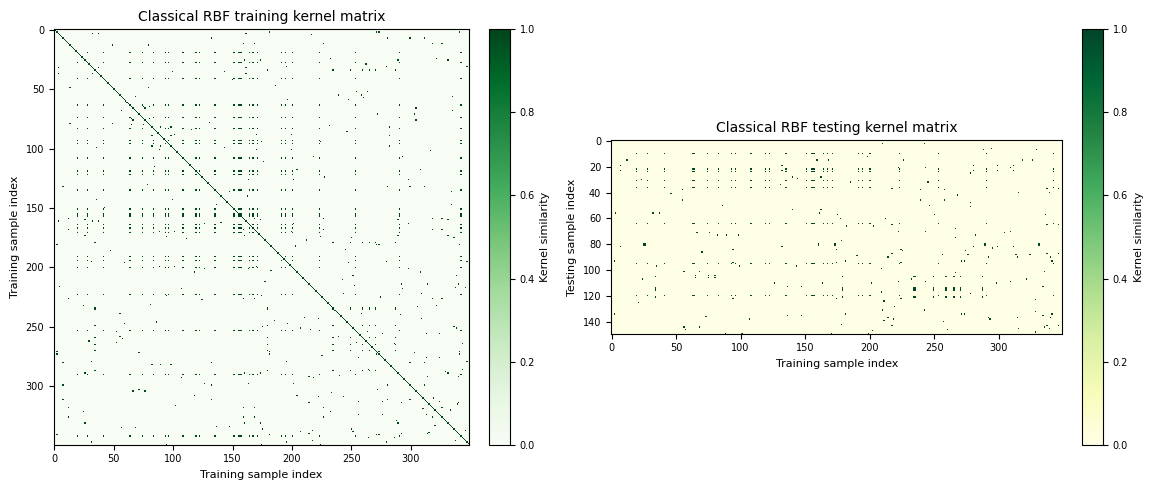


CLASSICAL RBF KERNEL SUMMARY
Features: ['e_cblp', 'SizeOfCode']
Training samples: 350
Testing samples: 150

Training kernel matrix shape: (350, 350)
  Mean similarity: 0.0121
  Std similarity: 0.1092
  Min similarity: 0.0000
  Max similarity: 1.0000

Testing kernel matrix shape: (150, 350)
  Mean similarity: 0.0088
  Std similarity: 0.0933
  Min similarity: 0.0000
  Max similarity: 1.0000
Using 2D features from hierarchical clustering: ['e_cblp', 'SizeOfCode']
Sampled 500 total samples: 250 class 0, 250 class 1
Creating quantum ZZFeatureMap kernel...
Computing quantum kernel matrices...


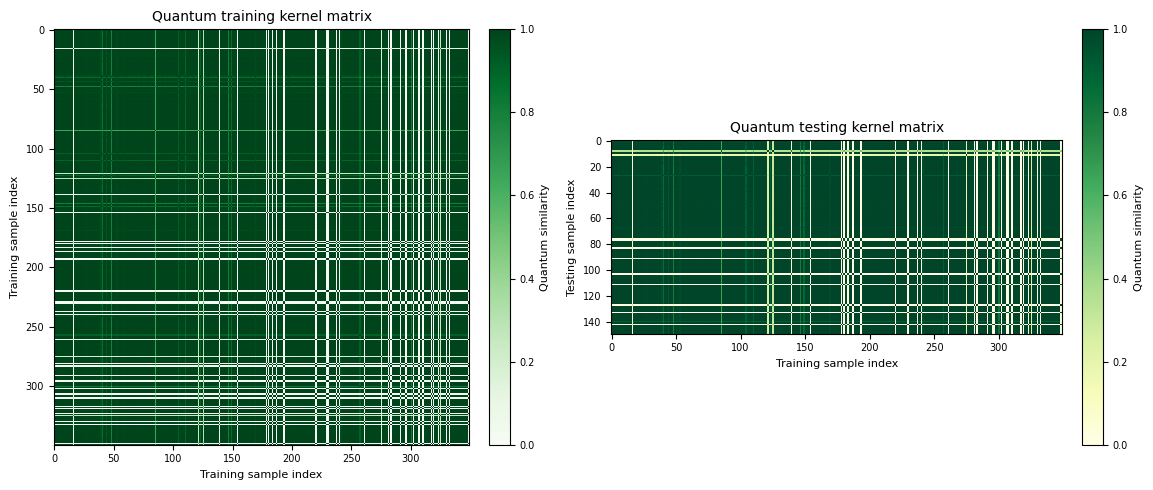


QUANTUM ZZFEATUREMAP KERNEL SUMMARY
Features: ['e_cblp', 'SizeOfCode']
Feature map: ZZFeatureMap (2 qubits, 2 reps)
Training samples: 350
Testing samples: 150

Training kernel matrix shape: (350, 350)
  Mean similarity: 0.8242
  Std similarity: 0.3606
  Min similarity: 0.0009
  Max similarity: 1.0000

Testing kernel matrix shape: (150, 350)
  Mean similarity: 0.8447
  Std similarity: 0.3447
  Min similarity: 0.0009
  Max similarity: 1.0000


In [57]:
# processor = MinimalDataProcessor(dataset_path="/path/to/dataset")
# feature_2to10 = processor.run_all(plotd=10)
df = processor.df
y = df['class']

# Run classical kernel
classical_train, classical_test = kernel(type="classical", feature_2to10=feature_2to10, df=df, y=y)

# Run quantum kernel  
quantum_train, quantum_test = kernel(type="quantum", feature_2to10=feature_2to10, df=df, y=y)


Generated feature_2to10 with 18 entries
  2D: 2 features - ['MajorSubsystemVersion', 'e_ip']
  3D: 3 features - ['MajorSubsystemVersion', 'e_ip', 'AddressOfEntryPoint']
  4D: 4 features - ['MajorSubsystemVersion', 'e_ip', 'SizeOfOptionalHeader', 'AddressOfEntryPoint']
  5D: 5 features - ['MajorSubsystemVersion', 'e_oeminfo', 'e_sp', 'SizeOfOptionalHeader', 'AddressOfEntryPoint']
  6D: 6 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'AddressOfEntryPoint']
  7D: 7 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'MajorSubsystemVersion', 'SizeOfOptionalHeader', 'SizeOfInitializedData', 'AddressOfEntryPoint']
  8D: 8 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'SizeOfHeapCommit', 'SizeOfOptionalHeader', 'SizeOfInitializedData', 'AddressOfEntryPoint', 'MajorSubsystemVersion']
  9D: 9 features - ['e_ovno', 'e_oeminfo', 'e_sp', 'PointerToSymbolTable', 'SizeOfOptionalHeader', 'SizeOfInitializedData', 'AddressOfEntryPoint', 'MajorSubsystemVersion', 'SizeOf

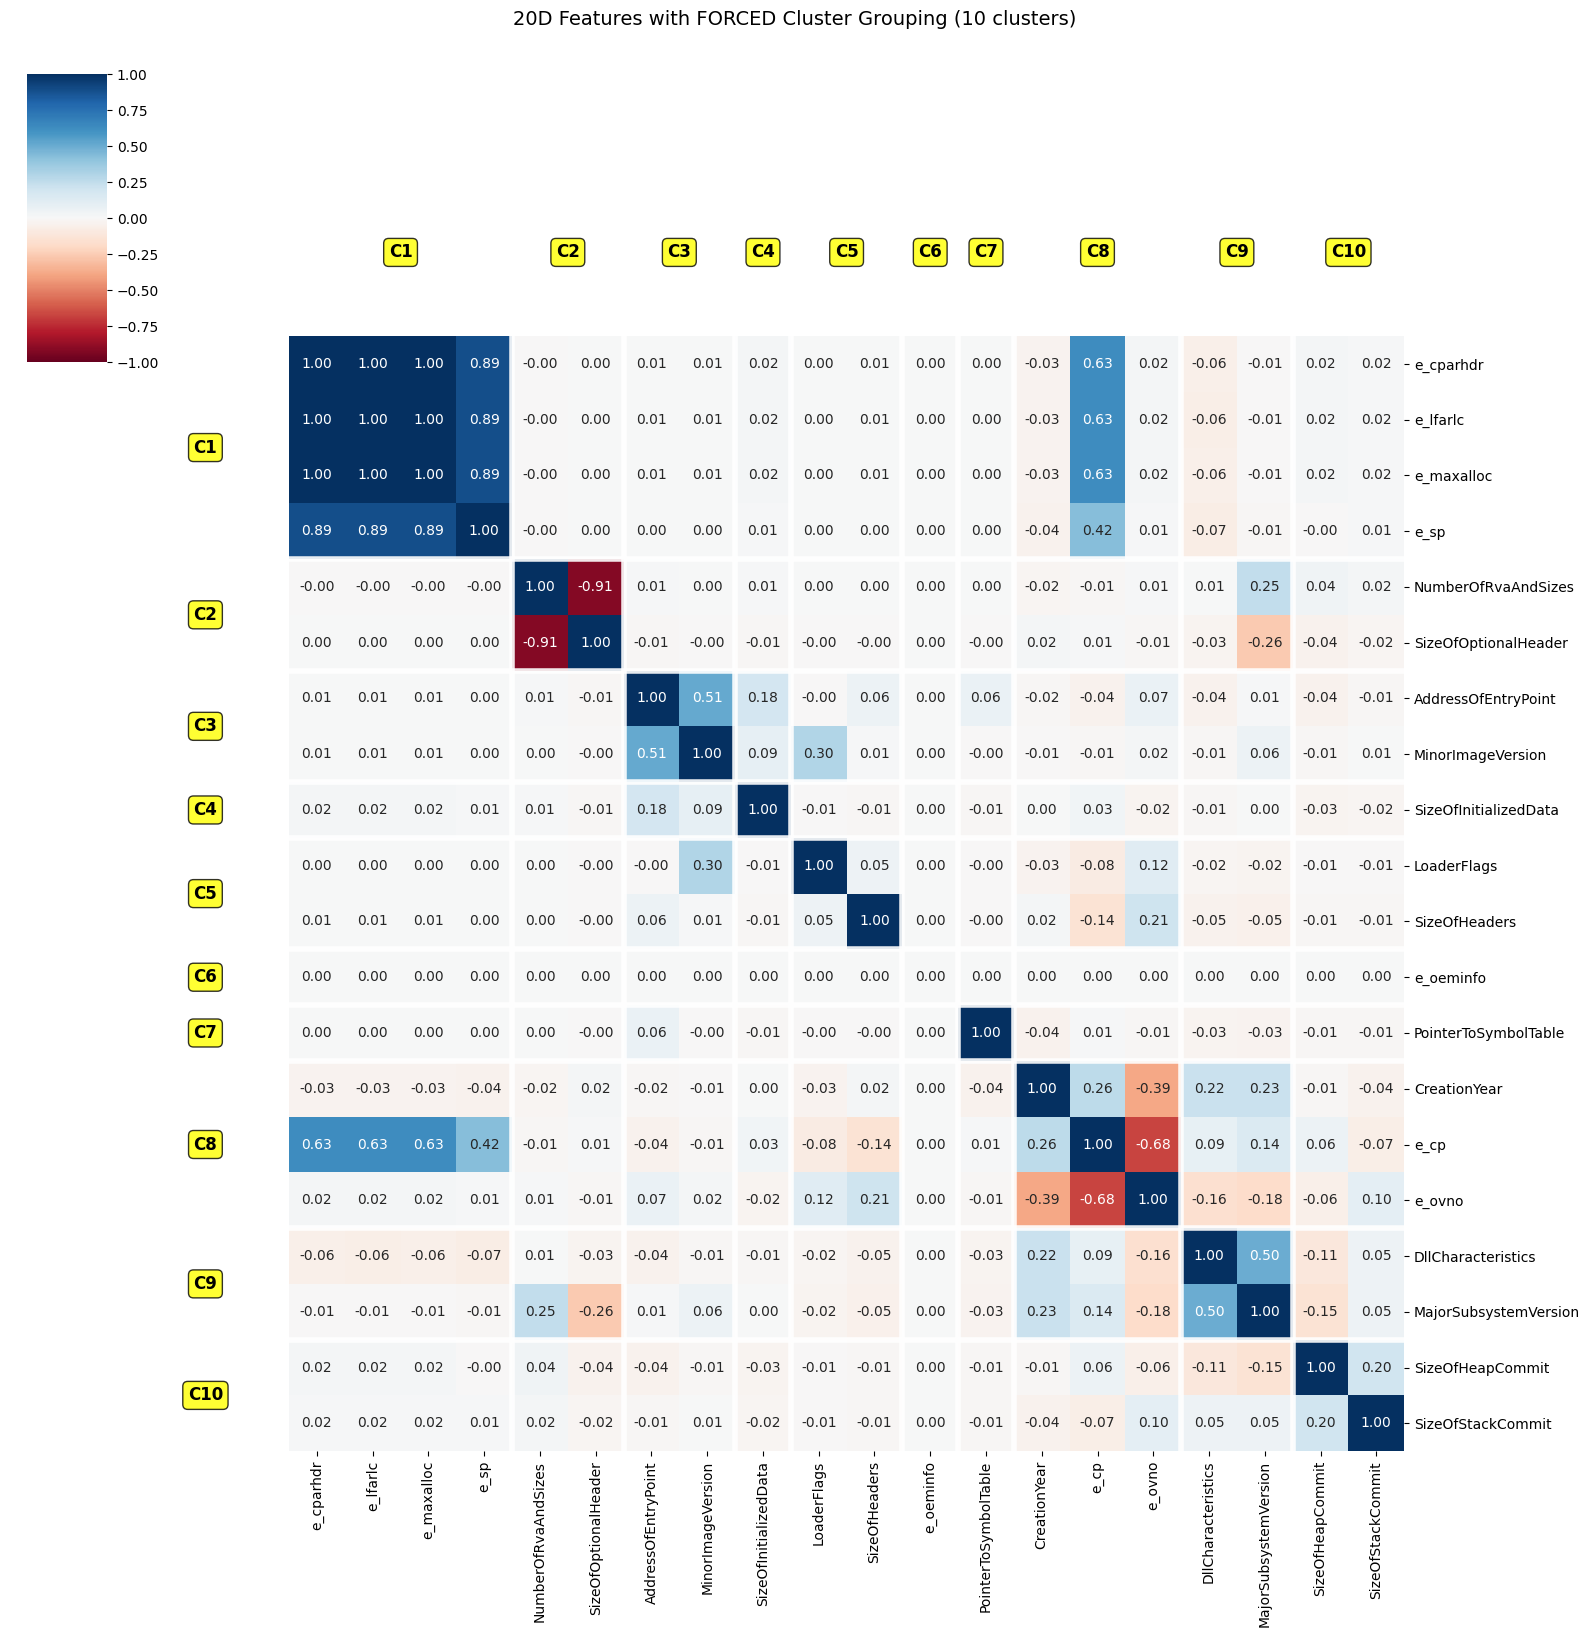


FORCED Cluster Summary for 20:
Features are GUARANTEED to be grouped by cluster (no dendrogram reordering)
Ordered features: ['e_cparhdr', 'e_lfarlc', 'e_maxalloc', 'e_sp', 'NumberOfRvaAndSizes', 'SizeOfOptionalHeader', 'AddressOfEntryPoint', 'MinorImageVersion', 'SizeOfInitializedData', 'LoaderFlags', 'SizeOfHeaders', 'e_oeminfo', 'PointerToSymbolTable', 'CreationYear', 'e_cp', 'e_ovno', 'DllCharacteristics', 'MajorSubsystemVersion', 'SizeOfHeapCommit', 'SizeOfStackCommit']

Cluster groups (in matrix order):
Cluster 1 (4 features): ['e_cparhdr', 'e_lfarlc', 'e_maxalloc', 'e_sp']
Cluster 2 (2 features): ['NumberOfRvaAndSizes', 'SizeOfOptionalHeader']
Cluster 3 (2 features): ['AddressOfEntryPoint', 'MinorImageVersion']
Cluster 4 (1 features): ['SizeOfInitializedData']
Cluster 5 (2 features): ['LoaderFlags', 'SizeOfHeaders']
Cluster 6 (1 features): ['e_oeminfo']
Cluster 7 (1 features): ['PointerToSymbolTable']
Cluster 8 (3 features): ['CreationYear', 'e_cp', 'e_ovno']
Cluster 9 (2 featu

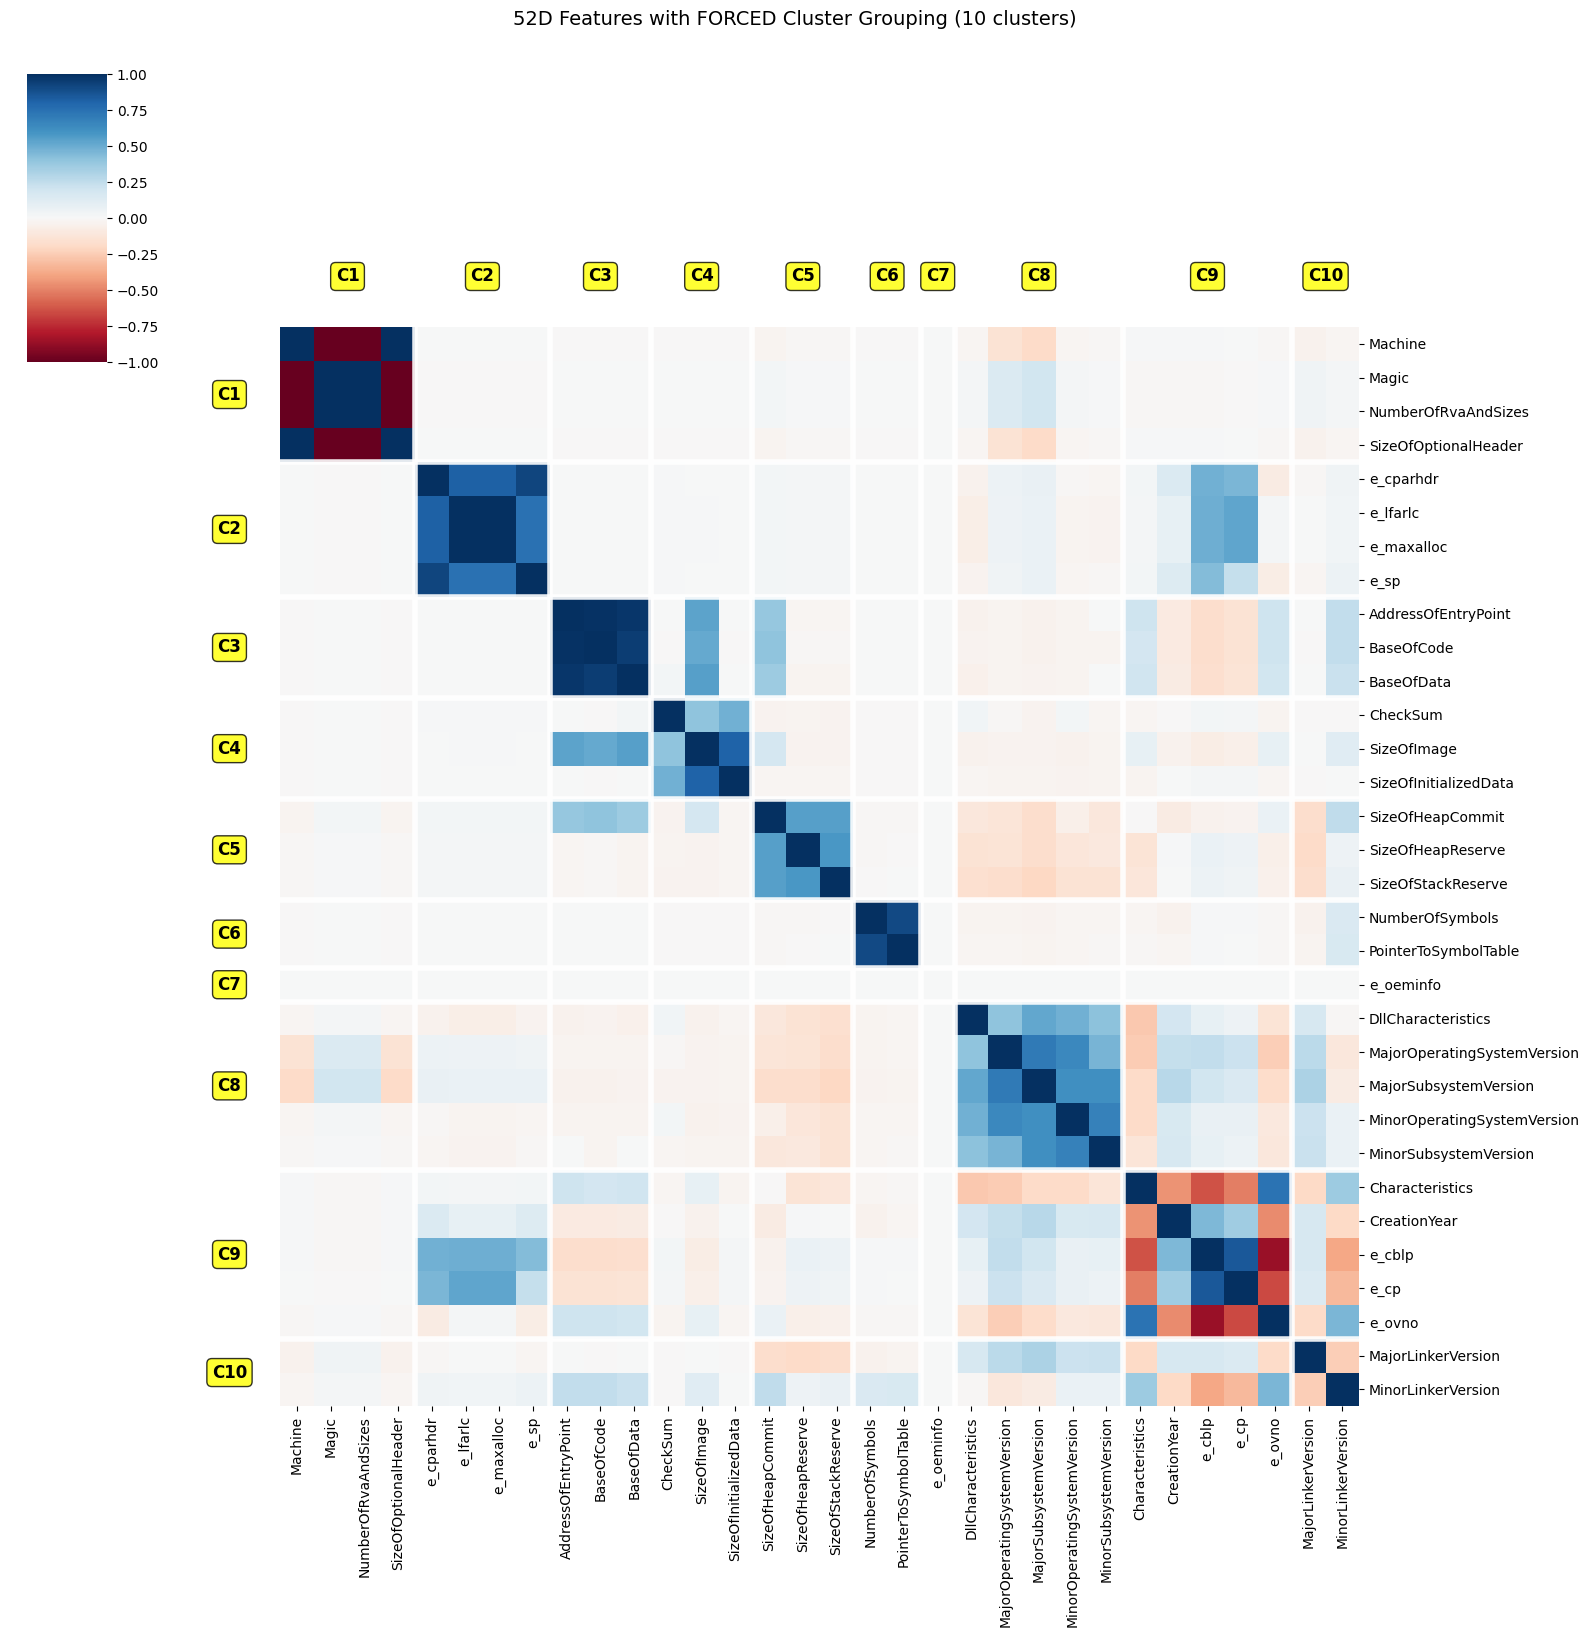


FORCED Cluster Summary for 52:
Features are GUARANTEED to be grouped by cluster (no dendrogram reordering)
Ordered features: ['Machine', 'Magic', 'NumberOfRvaAndSizes', 'SizeOfOptionalHeader', 'e_cparhdr', 'e_lfarlc', 'e_maxalloc', 'e_sp', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'CheckSum', 'SizeOfImage', 'SizeOfInitializedData', 'SizeOfHeapCommit', 'SizeOfHeapReserve', 'SizeOfStackReserve', 'NumberOfSymbols', 'PointerToSymbolTable', 'e_oeminfo', 'DllCharacteristics', 'MajorOperatingSystemVersion', 'MajorSubsystemVersion', 'MinorOperatingSystemVersion', 'MinorSubsystemVersion', 'Characteristics', 'CreationYear', 'e_cblp', 'e_cp', 'e_ovno', 'MajorLinkerVersion', 'MinorLinkerVersion']

Cluster groups (in matrix order):
Cluster 1 (4 features): ['Machine', 'Magic', 'NumberOfRvaAndSizes', 'SizeOfOptionalHeader']
Cluster 2 (4 features): ['e_cparhdr', 'e_lfarlc', 'e_maxalloc', 'e_sp']
Cluster 3 (3 features): ['AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData']
Cluster 4 (3 features

[['MajorSubsystemVersion', 'e_ip'],
 ['MajorSubsystemVersion', 'e_ip', 'AddressOfEntryPoint'],
 ['MajorSubsystemVersion',
  'e_ip',
  'SizeOfOptionalHeader',
  'AddressOfEntryPoint'],
 ['MajorSubsystemVersion',
  'e_oeminfo',
  'e_sp',
  'SizeOfOptionalHeader',
  'AddressOfEntryPoint'],
 ['e_ovno',
  'e_oeminfo',
  'e_sp',
  'MajorSubsystemVersion',
  'SizeOfOptionalHeader',
  'AddressOfEntryPoint'],
 ['e_ovno',
  'e_oeminfo',
  'e_sp',
  'MajorSubsystemVersion',
  'SizeOfOptionalHeader',
  'SizeOfInitializedData',
  'AddressOfEntryPoint'],
 ['e_ovno',
  'e_oeminfo',
  'e_sp',
  'SizeOfHeapCommit',
  'SizeOfOptionalHeader',
  'SizeOfInitializedData',
  'AddressOfEntryPoint',
  'MajorSubsystemVersion'],
 ['e_ovno',
  'e_oeminfo',
  'e_sp',
  'PointerToSymbolTable',
  'SizeOfOptionalHeader',
  'SizeOfInitializedData',
  'AddressOfEntryPoint',
  'MajorSubsystemVersion',
  'SizeOfHeapCommit'],
 ['e_ovno',
  'e_maxalloc',
  'e_sp',
  'e_oeminfo',
  'PointerToSymbolTable',
  'SizeOfOptionalH

In [76]:
processor.run_all(plotd=20) 
# force everione in the cluster be together in the correlation matrix and allow us to be able to call processor.run_all(plotd="all") to get all atributs of df in this hierarchical cluater correlation
processor.run_all(plotd=52) 

# Model Training

In [77]:
import pandas as pd
import numpy as np
import time
import os
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score)
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# ─────────────────────────────────────────────────────────────────────────────
# Canonical CSV header — EVERY results file uses exactly these columns
# ─────────────────────────────────────────────────────────────────────────────
RESULT_COLUMNS = [
    'Model', 'Fold',
    'TP', 'TN', 'FP', 'FN',
    'Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score',
    'Elapsed Time (s)', 'Usage (s)', 'Estimated Usage (s)',
    'Num Qubits', 'Median T1', 'Median T2', 'Median Read Out Error'
]

os.makedirs('results', exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# Feature-selection strategies
# ─────────────────────────────────────────────────────────────────────────────

def get_highest_corr_features(df, target_col, n):
    """
    Strategy 1 — Highest Correlation:
    Select the n features most positively/negatively correlated with the target.
    (FIX: uses feature-target correlation, NOT feature-feature correlation)
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    corr = X.corrwith(y).abs().sort_values(ascending=False)
    return corr.index[:n].tolist()


def get_highest_lowest_corr_features(df, target_col, n):
    """
    Strategy 2 — Highest + Lowest Correlation:
    Take the top n//2 and bottom n//2 features by |correlation with target|.
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    corr = X.corrwith(y).abs().sort_values(ascending=False)
    top    = n // 2
    bottom = n - top
    return corr.index[:top].tolist() + corr.index[-bottom:].tolist()


def get_hierarchical_corr_features(df, target_col, n):
    """
    Strategy 3 — Hierarchical Clustering Correlation:
    Build n clusters from feature-feature correlation, pick one representative
    per cluster (the feature most correlated with target within its cluster).
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Remove constant columns
    X = X.loc[:, X.std() > 1e-6]

    corr_ff = X.corr().abs().fillna(0).clip(0, 1)
    dissim  = (1 - corr_ff)
    dissim  = (dissim + dissim.T) / 2
    np.fill_diagonal(dissim.values, 0)
    dissim  = dissim.clip(0, None)

    try:
        Z = linkage(squareform(dissim), 'ward')
    except ValueError:
        Z = linkage(squareform(dissim), 'average')

    labels = fcluster(Z, n, criterion='maxclust')

    # Within each cluster pick the feature most correlated with the target
    corr_target = X.corrwith(y).abs()
    clusters = {}
    for feat, lab in zip(X.columns, labels):
        clusters.setdefault(lab, []).append(feat)

    representatives = []
    for lab in sorted(clusters):
        feats = clusters[lab]
        best  = max(feats, key=lambda f: corr_target.get(f, 0))
        representatives.append(best)

    return representatives[:n]


def clean_df(df, target_col):
    """
    Drop columns that are entirely NaN, then median-impute remaining NaNs.
    Returns a clean copy — does NOT modify the original df.
    """
    df = df.copy()
    # Drop columns where ALL values are NaN
    df = df.dropna(axis=1, how='all')
    # Median-impute remaining NaN values (per column)
    num_cols = df.columns.difference([target_col])
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    return df


# Map strategy name → function
FEATURE_STRATEGIES = {
    'high_corr'  : get_highest_corr_features,
    'high_low'   : get_highest_lowest_corr_features,
    'hierarchical': get_hierarchical_corr_features,
}


# ─────────────────────────────────────────────────────────────────────────────
# Metric helpers
# ─────────────────────────────────────────────────────────────────────────────

def compute_metrics(y_true, y_pred):
    """Return dict with TP/TN/FP/FN and all scalar classification metrics."""
    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = 0; tp = len(y_true)
    accuracy    = accuracy_score(y_true, y_pred)
    precision   = precision_score(y_true, y_pred,
                                  average='weighted', zero_division=0)
    sensitivity = recall_score(y_true, y_pred,
                                average='weighted', zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred,
                           average='weighted', zero_division=0)
    return dict(TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Accuracy=accuracy, Precision=precision,
                Sensitivity=sensitivity, Specificity=specificity,
                **{'F1 Score': f1})


def empty_quantum_metrics():
    return {'Usage (s)': 0, 'Estimated Usage (s)': 0, 'Num Qubits': 0,
            'Median T1': 0, 'Median T2': 0, 'Median Read Out Error': 0}


def make_row(model_name, fold_label, metrics_dict, elapsed, quantum_dict=None):
    """Build one result row as a single-row DataFrame in RESULT_COLUMNS order."""
    qm = quantum_dict or empty_quantum_metrics()
    row = {
        'Model'               : model_name,
        'Fold'                : fold_label,
        **metrics_dict,
        'Elapsed Time (s)'   : elapsed,
        **qm,
    }
    return pd.DataFrame([{col: row.get(col, 0) for col in RESULT_COLUMNS}])


# ─────────────────────────────────────────────────────────────────────────────
# CSV helpers
# ─────────────────────────────────────────────────────────────────────────────

def init_csv(path):
    """Create CSV with header if it does not exist."""
    if not os.path.exists(path):
        pd.DataFrame(columns=RESULT_COLUMNS).to_csv(path, index=False)


def append_row(path, row_df):
    """Append one row to CSV (header already written by init_csv)."""
    row_df.to_csv(path, mode='a', header=False, index=False)


def row_exists(path, model_name, fold_label):
    """Return True if (model_name, fold_label) already in the CSV."""
    if not os.path.exists(path):
        return False
    df = pd.read_csv(path, usecols=['Model', 'Fold'])
    return ((df['Model'] == model_name) &
            (df['Fold'].astype(str) == str(fold_label))).any()


# ─────────────────────────────────────────────────────────────────────────────
# Model trainers — one function per model type
# ─────────────────────────────────────────────────────────────────────────────

def train_svc(X_tr, y_tr, X_te, y_te):
    """Classical SVC with RBF kernel + StandardScaler + median imputation."""
    pipe = make_pipeline(
        SimpleImputer(strategy='median'),   # handles any residual NaNs
        StandardScaler(),
        SVC(kernel='rbf', random_state=42)
    )
    pipe.fit(X_tr, y_tr)
    return pipe.predict(X_te), empty_quantum_metrics()


def train_svc_qkernel(X_tr, y_tr, X_te, y_te, n_features, service=None, backend_name=None):
    """
    SVC with precomputed quantum kernel (ZZFeatureMap).
    Falls back to simulator (StatevectorSampler) when no IBM service provided.
    """
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    from qiskit.circuit.library import ZZFeatureMap

    # Impute then scale (NaN-safe)
    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(imputer.fit_transform(X_tr))
    X_te_s  = scaler.transform(imputer.transform(X_te))

    feature_map = ZZFeatureMap(feature_dimension=n_features, reps=2)
    qkernel     = FidelityQuantumKernel(feature_map=feature_map)

    K_train = qkernel.evaluate(x_vec=X_tr_s)
    K_test  = qkernel.evaluate(x_vec=X_te_s, y_vec=X_tr_s)

    model = SVC(kernel='precomputed', random_state=42)
    model.fit(K_train, y_tr)
    return model.predict(K_test), empty_quantum_metrics()


def train_qsvc(X_tr, y_tr, X_te, y_te, n_features, service=None, backend_name=None):
    """
    QSVC using ZZFeatureMap quantum kernel.
    If service + backend_name are provided, runs on IBM hardware;
    otherwise runs on the local statevector simulator.
    """
    from qiskit.circuit.library import ZZFeatureMap
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    from qiskit_machine_learning.algorithms import QSVC

    # Impute then scale (NaN-safe)
    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(imputer.fit_transform(X_tr))
    X_te_s  = scaler.transform(imputer.transform(X_te))

    feature_map = ZZFeatureMap(feature_dimension=n_features, reps=2)

    if service is not None and backend_name is not None:
        from qiskit_ibm_runtime import SamplerV2 as Sampler
        backend     = service.backend(backend_name)
        from qiskit import transpile
        fm_compiled = transpile(feature_map, backend=backend)
        qkernel     = FidelityQuantumKernel(feature_map=fm_compiled)
    else:
        qkernel = FidelityQuantumKernel(feature_map=feature_map)

    model = QSVC(quantum_kernel=qkernel)
    model.fit(X_tr_s, y_tr)
    return model.predict(X_te_s), empty_quantum_metrics()


# ─────────────────────────────────────────────────────────────────────────────
# Core 10-fold CV loop with best/worst retrain
# ─────────────────────────────────────────────────────────────────────────────

def run_cv(df, target_col, feature_strategy, n_features,
           model_type, csv_path,
           n_splits=10, service=None, backend_name=None):
    """
    Run 10-fold Stratified CV for one (strategy × dimension × model) combination.

    Model name written to CSV:
        <MODEL>_<STRATEGY>_<N>D
        e.g.  SVC_high_corr_4D,  SVCQK_high_low_7D,  QSVC_hierarchical_3D

    Rows per call (written to csv_path immediately):
        folds 1-10  → Fold = 1 … 10
        retrained   → Model = <name>_retrained, Fold = "<best_fold>_retrained"

    Parameters
    ----------
    df              : pd.DataFrame  full dataset (features + target)
    target_col      : str           name of the target column
    feature_strategy: str           one of 'high_corr', 'high_low', 'hierarchical'
    n_features      : int           number of features (2-10)
    model_type      : str           'svc', 'svc_qkernel', or 'qsvc'
    csv_path        : str           path to results CSV
    n_splits        : int           number of CV folds (default 10)
    service         : QiskitRuntimeService or None
    backend_name    : str or None   IBM backend name for quantum models
    """
    # Clean the dataset first (drop all-NaN columns, impute remaining NaNs)
    df = clean_df(df, target_col)

    # Build feature list for this strategy × dimension
    feat_fn   = FEATURE_STRATEGIES[feature_strategy]
    features  = feat_fn(df, target_col, n_features)
    X         = df[features].values
    y         = df[target_col]

    model_prefix = {'svc': 'SVC', 'svc_qkernel': 'SVCQK', 'qsvc': 'QSVC'}[model_type]
    model_name   = f"{model_prefix}_{feature_strategy}_{n_features}D"
    retrain_name = f"{model_name}_retrained"

    print(f"\n  {model_name}  |  features: {features}")

    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    splits = list(skf.split(X, y))

    fold_records    = []   # (fold_num, precision, train_idx, test_idx)

    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        fold_num = fold_idx + 1

        if row_exists(csv_path, model_name, fold_num):
            # Already saved — recover precision from CSV for best/worst logic
            saved = pd.read_csv(csv_path)
            mask  = (saved['Model'] == model_name) & (saved['Fold'].astype(str) == str(fold_num))
            prec  = float(saved.loc[mask, 'Precision'].iloc[0])
            fold_records.append((fold_num, prec, train_idx, test_idx))
            print(f"    fold {fold_num:2d} ⏭  (already saved, Precision={prec:.4f})")
            continue

        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        t0 = time.time()
        if model_type == 'svc':
            y_pred, q_metrics = train_svc(X_tr, y_tr, X_te, y_te)
        elif model_type == 'svc_qkernel':
            y_pred, q_metrics = train_svc_qkernel(
                X_tr, y_tr, X_te, y_te, n_features, service, backend_name)
        elif model_type == 'qsvc':
            y_pred, q_metrics = train_qsvc(
                X_tr, y_tr, X_te, y_te, n_features, service, backend_name)
        elapsed = time.time() - t0

        metrics = compute_metrics(y_te, y_pred)
        row     = make_row(model_name, fold_num, metrics, elapsed, q_metrics)
        append_row(csv_path, row)

        prec = metrics['Precision']
        fold_records.append((fold_num, prec, train_idx, test_idx))
        print(f"    fold {fold_num:2d}  Precision={prec:.4f}  Accuracy={metrics['Accuracy']:.4f}"
              f"  ({elapsed:.2f}s)")

    # ── Best / Worst retrain ──────────────────────────────────────────────
    precisions  = [r[1] for r in fold_records]
    best_idx    = int(np.argmax(precisions))
    worst_idx   = int(np.argmin(precisions))
    best_fold   = fold_records[best_idx]
    worst_fold  = fold_records[worst_idx]
    retrain_lbl = f"{best_fold[0]}_retrained"

    print(f"\n    Best  fold: {best_fold[0]}  (Precision={best_fold[1]:.4f})")
    print(f"    Worst fold: {worst_fold[0]}  (Precision={worst_fold[1]:.4f})")
    print(f"    → Retrain: best-fold training data  →  worst-fold test data")

    if row_exists(csv_path, retrain_name, retrain_lbl):
        print(f"    ⏭  retrained row already saved")
    else:
        X_best_tr = X[best_fold[2]]
        y_best_tr = y.iloc[best_fold[2]]
        X_worst_te = X[worst_fold[3]]
        y_worst_te = y.iloc[worst_fold[3]]

        t0 = time.time()
        if model_type == 'svc':
            y_pred_r, q_metrics_r = train_svc(X_best_tr, y_best_tr, X_worst_te, y_worst_te)
        elif model_type == 'svc_qkernel':
            y_pred_r, q_metrics_r = train_svc_qkernel(
                X_best_tr, y_best_tr, X_worst_te, y_worst_te,
                n_features, service, backend_name)
        elif model_type == 'qsvc':
            y_pred_r, q_metrics_r = train_qsvc(
                X_best_tr, y_best_tr, X_worst_te, y_worst_te,
                n_features, service, backend_name)
        elapsed_r = time.time() - t0

        metrics_r = compute_metrics(y_worst_te, y_pred_r)
        row_r     = make_row(retrain_name, retrain_lbl, metrics_r, elapsed_r, q_metrics_r)
        append_row(csv_path, row_r)
        print(f"    retrained  Precision={metrics_r['Precision']:.4f}"
              f"  Accuracy={metrics_r['Accuracy']:.4f}")

    return csv_path


# ─────────────────────────────────────────────────────────────────────────────
# Top-level runner — all 3 models × 3 strategies × 2-10D
# ─────────────────────────────────────────────────────────────────────────────

def run_all_experiments(df, target_col='class',
                        service=None, backend_name=None,
                        n_splits=10,
                        dim_range=range(2, 11)):
    """
    Run the full experiment grid:
        Models     : SVC, SVC+QKernel, QSVC
        Strategies : high_corr, high_low, hierarchical
        Dimensions : 2 → 10  (one CSV per model)

    CSVs produced:
        results/df_svc.csv
        results/df_svc_qkernel.csv
        results/df_qsvc.csv

    Each CSV has the canonical header:
        Model, Fold, TP, TN, FP, FN, Accuracy, Precision, Sensitivity,
        Specificity, F1 Score, Elapsed Time (s), Usage (s),
        Estimated Usage (s), Num Qubits, Median T1, Median T2,
        Median Read Out Error
    """
    csv_map = {
        'svc'        : 'results/df_svc.csv',
        'svc_qkernel': 'results/df_svc_qkernel.csv',
        'qsvc'       : 'results/df_qsvc.csv',
    }

    # Initialise all CSVs with header
    for path in csv_map.values():
        init_csv(path)

    strategies = list(FEATURE_STRATEGIES.keys())
    models     = list(csv_map.keys())

    for model_type in models:
        csv_path = csv_map[model_type]
        print(f"\n{'='*70}")
        print(f"  MODEL: {model_type.upper()}")
        print(f"  CSV  : {csv_path}")
        print(f"{'='*70}")

        for strategy in strategies:
            print(f"\n  Strategy: {strategy}")
            for n_feat in dim_range:
                run_cv(
                    df=df,
                    target_col=target_col,
                    feature_strategy=strategy,
                    n_features=n_feat,
                    model_type=model_type,
                    csv_path=csv_path,
                    n_splits=n_splits,
                    service=service,
                    backend_name=backend_name,
                )

    print(f"\n✅ All experiments done.")
    print(f"   results/df_svc.csv        — Classical SVC")
    print(f"   results/df_svc_qkernel.csv — SVC + Quantum Kernel")
    print(f"   results/df_qsvc.csv        — QSVC")
    return csv_map


# ─────────────────────────────────────────────────────────────────────────────
# Plotting helper
# ─────────────────────────────────────────────────────────────────────────────

def plot_results(csv_path, metric='Precision', title=None):
    """
    Load a results CSV and plot metric vs dimension for each strategy,
    showing the 10-fold mean ± std bands.
    Retrained rows are excluded from the line plots (kept in CSV only).
    """
    import matplotlib.pyplot as plt

    df_r = pd.read_csv(csv_path)
    df_r = df_r[~df_r['Model'].str.contains('retrained', case=False, na=False)]

    # Parse strategy and dimension from model name
    # Format: <PREFIX>_<strategy_part>_<N>D
    def parse(model_str):
        parts = model_str.split('_')
        try:
            # Last part is NNd
            dim = int(parts[-1].replace('D', ''))
            strategy = '_'.join(parts[1:-1])
            return strategy, dim
        except Exception:
            return None, None

    df_r[['strategy', 'dim']] = df_r['Model'].apply(
        lambda m: pd.Series(parse(m)))
    df_r = df_r.dropna(subset=['strategy', 'dim'])
    df_r['dim'] = df_r['dim'].astype(int)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {'high_corr': 'tab:blue', 'high_low': 'tab:orange',
              'hierarchical': 'tab:green'}
    labels = {'high_corr':   'Highest Corr.',
              'high_low':    'Highest + Lowest Corr.',
              'hierarchical': 'Hierarchical Clustering'}

    for strategy in FEATURE_STRATEGIES:
        sub = df_r[df_r['strategy'] == strategy].groupby('dim')[metric]
        means = sub.mean()
        stds  = sub.std().fillna(0)
        dims  = means.index.tolist()
        ax.plot(dims, means.values, 'o-',
                color=colors[strategy], label=labels[strategy], linewidth=2)
        ax.fill_between(dims,
                        means.values - stds.values,
                        means.values + stds.values,
                        alpha=0.15, color=colors[strategy])

    ax.set_xlabel('Number of Features (Dimensions)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title or f"{metric} vs Dimensions\n({csv_path})", fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Experiment Design

Three **model types** × three **feature-selection strategies** × nine **dimensionalities** (2-10):

| Model | Description | CSV |
|---|---|---|
| `SVC` | Classical SVC (RBF kernel) | `results/df_svc.csv` |
| `SVCQK` | SVC with precomputed ZZFeatureMap quantum kernel | `results/df_svc_qkernel.csv` |
| `QSVC` | Full QSVC (IBM quantum / local simulator) | `results/df_qsvc.csv` |

| Strategy key | Description |
|---|---|
| `high_corr` | Top-n features by |correlation with target| |
| `high_low` | Top-n/2 + bottom-n/2 by |correlation with target| |
| `hierarchical` | One representative per hierarchical-clustering cluster (best target-corr per cluster) |

**Model name format in CSV:** `<PREFIX>_<strategy>_<N>D`  
e.g. `SVC_high_corr_4D`, `SVCQK_high_low_7D`, `QSVC_hierarchical_3D`

**Per-dimension rows:**  10 fold rows (Fold = 1-10) + 1 retrained row  
(`Model = <name>_retrained`, `Fold = "<best_fold>_retrained"`)

**Resume-safe:** every fold is written to CSV immediately; already-saved folds are skipped.


In [78]:
# ── Classical SVC ─────────────────────────────────────────────────────────────
# Runs SVC (RBF) for all 3 feature strategies × 2D-10D with 10-fold CV.
# Results saved to results/df_svc.csv immediately (resume-safe).

csv_svc = 'results/df_svc.csv'
init_csv(csv_svc)

for strategy in FEATURE_STRATEGIES:
    print(f"\nStrategy: {strategy}")
    for n_feat in range(2, 11):
        run_cv(df=df, target_col=target,
               feature_strategy=strategy,
               n_features=n_feat,
               model_type='svc',
               csv_path=csv_svc)

print("\n✅ SVC done →", csv_svc)



Strategy: high_corr

  SVC_high_corr_2D  |  features: ['ImageBase', 'MinorSubsystemVersion']
    fold  1 ⏭  (already saved, Precision=0.8914)
    fold  2 ⏭  (already saved, Precision=0.8472)
    fold  3 ⏭  (already saved, Precision=0.8968)
    fold  4 ⏭  (already saved, Precision=0.8472)
    fold  5 ⏭  (already saved, Precision=0.8183)
    fold  6 ⏭  (already saved, Precision=0.9098)
    fold  7 ⏭  (already saved, Precision=0.8565)
    fold  8 ⏭  (already saved, Precision=0.8846)
    fold  9 ⏭  (already saved, Precision=0.9031)
    fold 10 ⏭  (already saved, Precision=0.8407)

    Best  fold: 6  (Precision=0.9098)
    Worst fold: 5  (Precision=0.8183)
    → Retrain: best-fold training data  →  worst-fold test data
    ⏭  retrained row already saved

  SVC_high_corr_3D  |  features: ['ImageBase', 'MinorSubsystemVersion', 'MajorSubsystemVersion']
    fold  1 ⏭  (already saved, Precision=0.9006)
    fold  2 ⏭  (already saved, Precision=0.8468)
    fold  3 ⏭  (already saved, Precision=0.8

In [79]:
# ── SVC + Quantum Kernel ──────────────────────────────────────────────────────
# Uses ZZFeatureMap to build a quantum kernel matrix, then fits a classical SVC.
# Runs on the local Qiskit statevector simulator by default.
# To use IBM hardware: pass service= and backend_name= to run_cv().
# Results saved to results/df_svc_qkernel.csv (resume-safe).

csv_qk = 'results/df_svc_qkernel.csv'
init_csv(csv_qk)

# Optional IBM hardware setup:
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_TOKEN")
# backend_name = "ibm_brisbane"
service = None; backend_name = None

for strategy in FEATURE_STRATEGIES:
    print(f"\nStrategy: {strategy}")
    for n_feat in range(2, 11):
        run_cv(df=df, target_col=target,
               feature_strategy=strategy,
               n_features=n_feat,
               model_type='svc_qkernel',
               csv_path=csv_qk,
               service=service,
               backend_name=backend_name)

print("\n✅ SVC+QKernel done →", csv_qk)



Strategy: high_corr

  SVCQK_high_corr_2D  |  features: ['ImageBase', 'MinorSubsystemVersion']


KeyboardInterrupt: 

In [ ]:
# ── QSVC ─────────────────────────────────────────────────────────────────────
# Full QSVC using ZZFeatureMap quantum kernel.
# Defaults to local statevector simulator.
# For IBM hardware: uncomment service/backend_name below.
# Results saved to results/df_qsvc.csv (resume-safe).

csv_qsvc = 'results/df_qsvc.csv'
init_csv(csv_qsvc)

# Optional IBM hardware setup:
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_TOKEN")
# backend_name = "ibm_brisbane"
service = None; backend_name = None

for strategy in FEATURE_STRATEGIES:
    print(f"\nStrategy: {strategy}")
    for n_feat in range(2, 11):
        run_cv(df=df, target_col=target,
               feature_strategy=strategy,
               n_features=n_feat,
               model_type='qsvc',
               csv_path=csv_qsvc,
               service=service,
               backend_name=backend_name)

print("\n✅ QSVC done →", csv_qsvc)


In [ ]:
# ── Run ALL models in one call (alternative to cells above) ──────────────────
# Uncomment to run the full grid automatically.

# service = None      # or QiskitRuntimeService(...)
# backend_name = None # or "ibm_brisbane"

# csv_map = run_all_experiments(
#     df=df,
#     target_col=target,
#     service=service,
#     backend_name=backend_name,
# )


# Metrics of Evaluation

📂 Loaded 99 existing results from results/df_svc.csv
📂 Loaded 99 records from results/df_svc.csv

LOADED RESULTS SUMMARY
 n_clusters  best_fold_score  worst_fold_score  retrained_score  avg_cv_score  std_cv_score  improvement
          2         0.560694          0.494208         0.473988      0.527963      0.023504    -0.086705
          3         0.722543          0.679537         0.705202      0.697919      0.017325    -0.017341
          4         0.604247          0.537572         0.610039      0.575429      0.019204     0.005792
          5         0.725869          0.681467         0.731660      0.703514      0.017427     0.005792
          6         0.723938          0.676301         0.720077      0.700815      0.019586    -0.003861
          7         0.722543          0.679537         0.720617      0.699849      0.017175    -0.001927
          8         0.722008          0.677606         0.722008      0.699657      0.017817     0.000000
          9         0.723938          0

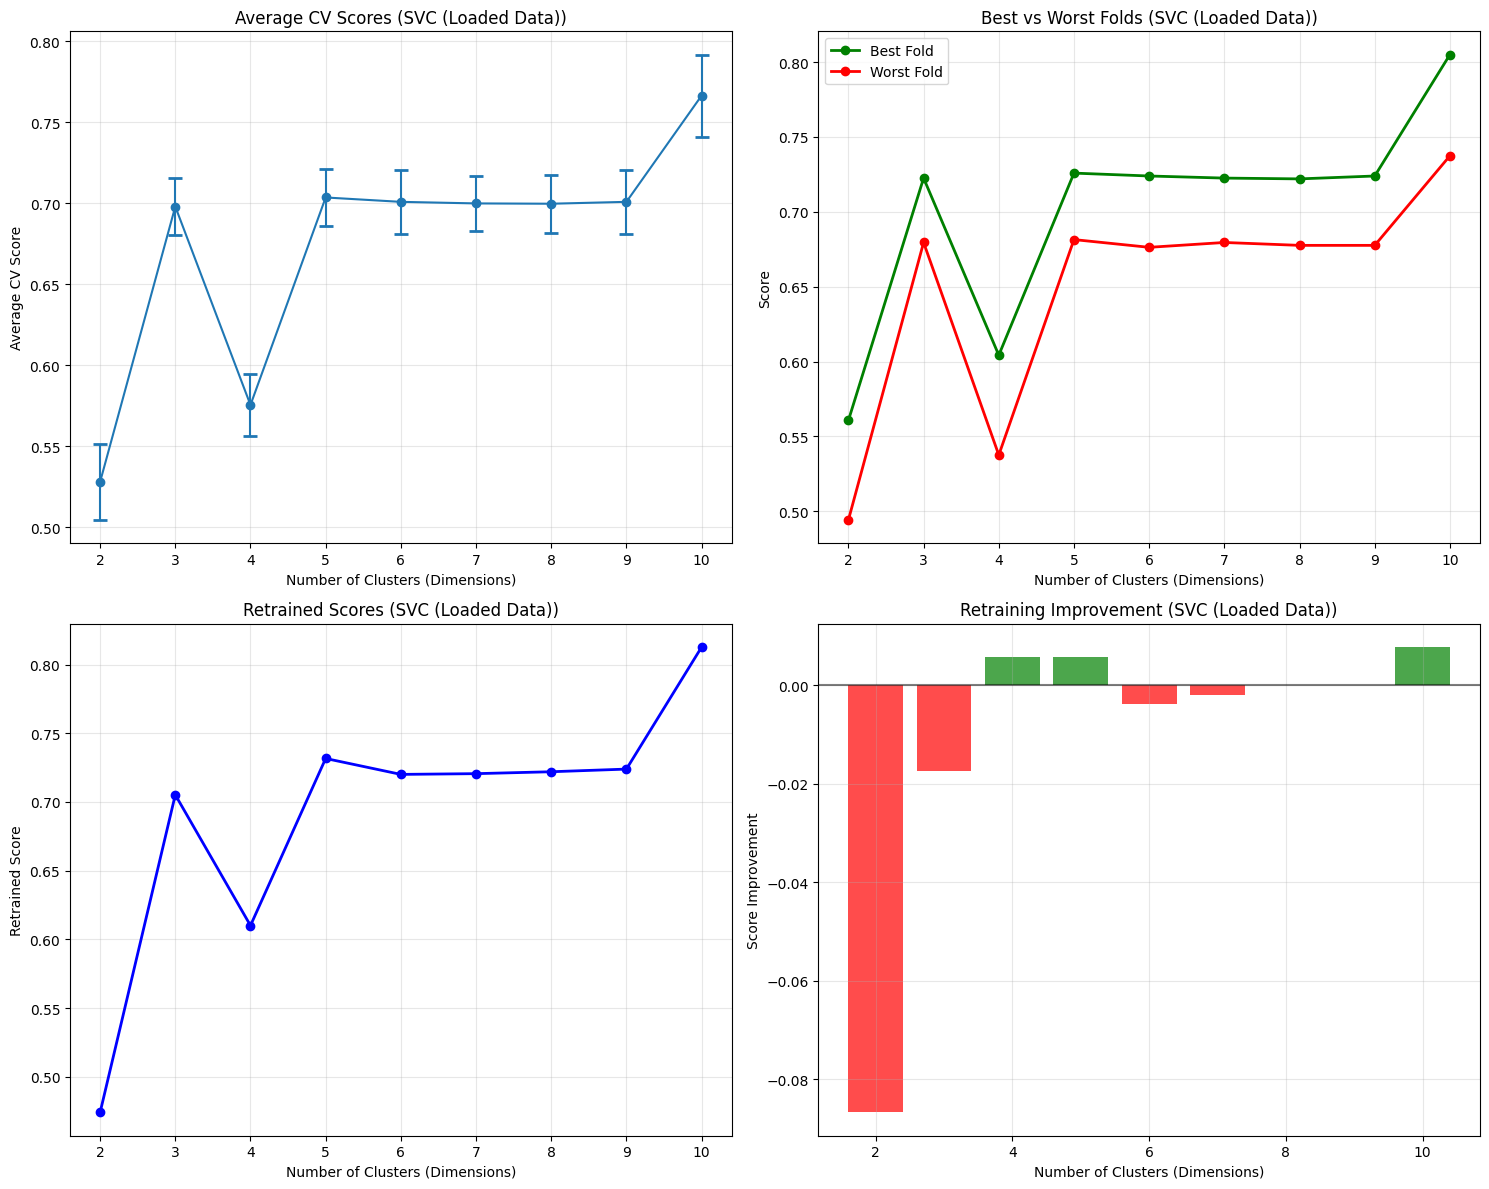

COMPARATIVE ANALYSIS: SVC vs QSVC
📂 Loaded 99 records from results/df_svc.csv
❌ File df_qsvc.csv not found!
❌ Could not load both datasets for comparison!


In [84]:
# ── Load and plot results ─────────────────────────────────────────────────────

# Classical SVC
plot_results('results/df_svc.csv',
             metric='Precision', title='Classical SVC — Precision vs Dimensions')

# SVC + Quantum Kernel
plot_results('results/df_svc_qkernel.csv',
             metric='Precision', title='SVC + Quantum Kernel — Precision vs Dimensions')

# QSVC
plot_results('results/df_qsvc.csv',
             metric='Precision', title='QSVC — Precision vs Dimensions')


In [ ]:
# ── Side-by-side comparison of all three models ───────────────────────────────
import matplotlib.pyplot as plt

metric = 'Precision'
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

titles = {
    'results/df_svc.csv'        : 'Classical SVC',
    'results/df_svc_qkernel.csv': 'SVC + Quantum Kernel',
    'results/df_qsvc.csv'       : 'QSVC',
}
colors = {'high_corr': 'tab:blue', 'high_low': 'tab:orange',
          'hierarchical': 'tab:green'}
labels = {'high_corr':   'Highest Corr.',
          'high_low':    'High + Low Corr.',
          'hierarchical': 'Hierarchical'}

for ax, (csv_path, title) in zip(axes, titles.items()):
    import os
    if not os.path.exists(csv_path):
        ax.set_title(f"{title}\n(no data yet)")
        continue

    df_r = pd.read_csv(csv_path)
    df_r = df_r[~df_r['Model'].str.contains('retrained', case=False, na=False)]

    def parse(m):
        parts = m.split('_')
        try:
            dim = int(parts[-1].replace('D', ''))
            strat = '_'.join(parts[1:-1])
            return strat, dim
        except: return None, None

    df_r[['strategy', 'dim']] = df_r['Model'].apply(lambda m: pd.Series(parse(m)))
    df_r = df_r.dropna(subset=['strategy', 'dim'])
    df_r['dim'] = df_r['dim'].astype(int)

    for strategy in FEATURE_STRATEGIES:
        sub = df_r[df_r['strategy'] == strategy].groupby('dim')[metric]
        means = sub.mean(); stds = sub.std().fillna(0)
        dims  = means.index.tolist()
        ax.plot(dims, means.values, 'o-',
                color=colors[strategy], label=labels[strategy], linewidth=2)
        ax.fill_between(dims,
                        means.values - stds.values,
                        means.values + stds.values,
                        alpha=0.15, color=colors[strategy])

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Dimensions')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(metric)
axes[0].legend(fontsize=9)
plt.suptitle(f"Malware Detection — {metric} by Model & Feature Strategy",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Tutorial for ARC UTSA Supercomputer
#### Commands to enter in ARC UTSA
ssh ats852@arc.utsa.edu

srun -p compute1 -n 1 -t 00:30:00 --pty bash
srun -p compute1 -n 1 -t 00:05:00 --cpus-per-task=32 --pty bash

module restore experiments

conda activate QUANTUM

#run the code

cd QML_in_SCM/src

python3 01_qml_in_scm.py

#### Vim Document
vim name_file.py            oppen file

a                           write file

ESC + dd                    delete the entire line

ESC + :w                    save the writing on file

ESC + :q                    close file

ESC + :wq                   save and close file

# Article Observations
* We are the first one to do an analogy in SCM and QML in a real quantum computer

Tougths:
* Fist is the dataset with highest corelations
* The problem is that we are doing feature selection based on the best features that are more corelated with our output. But we want to have features that are now as good to our output. Like the best corelated and the least corelated for example

Hipothesis:
- The results might be different
- Superconducting qubit with

- Get the time for predicting the test data